# Load modules

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
from shapely.geometry import Polygon

In [2]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [3]:
project_name='260105 seeded'
if not os.path.exists('plots/'+project_name):
    os.mkdir('plots/'+project_name)
if not os.path.exists('Processed data/'+project_name):
    os.mkdir('Processed data/'+project_name)
if not os.path.exists('Raw data/'+project_name):
    os.mkdir('Raw data/'+project_name)

# Load data

## Batch files

In [4]:
def read_batch_file(path):
    start = pl.read_csv(path).with_row_index().filter(pl.col('[Header]')=='[Batch Table]')['index'][0]+2
    nrows = int(pl.read_csv(path,
                skip_rows=start,has_header=False,n_rows=1)[0,0].split('\t')[-1])
    return pl.read_csv(path,
                skip_rows=start+1,has_header=True,n_rows=nrows,separator='\t')

In [5]:
b0 = read_batch_file('Processed data/batch files/240428-std curve.txt')
b1 = read_batch_file('Processed data/batch files/260105 seeded temp sol.txt')

batch = pl.concat([b0,b1])
batch

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data File,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard:(I)""",null,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.33pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…",0,null,2,9.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""B12""","""21c7d_B""",61,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_21c7d_B…",0,null,0,49.8,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""C12""","""37c7d_B""",62,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_37c7d_B…",0,null,0,49.8,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""D11""","""60c2d_B""",63,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_60c2d_B…",0,null,0,49.8,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null


In [6]:
batch=batch.rename({'Data File':'Data Filename'})

## UV

In [7]:
summary205 = pl.read_csv('Processed data/'+project_name+'/UV quant table.txt',
                         skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summary205

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
1,"""260105 seeded temp sol_none_na…","""Control""","""none""","""-1""",null,null,null,null,null,null,null,null,null,null,null,null
2,"""260105 seeded temp sol_buffer_…","""Control""","""buffer""","""F1""",null,null,null,null,null,null,null,null,null,null,null,null
3,"""260105 seeded temp sol_frozen …","""Control""","""frozen monomer 8.2 uM""","""F2""",4.347,588870.0,25.008,174828.0,null,null,null,4.1,4.6,0.13,1895.1,1.827
4,"""260105 seeded temp sol_frozen …","""Control""","""frozen monomer 0.82 uM""","""F3""",4.325,232499.0,9.821,74787.0,null,null,null,4.1,4.6,0.13,732.56,1.912
5,"""260105 seeded temp sol_10c2d_1…","""Unknown""","""10c2d_1""","""A1""",4.332,42814.0,1.738,11511.0,null,null,null,4.1,4.6,0.11,159.26,1.629
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
74,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.4,69327.0,2.868,33570.0,3.0,95.6,"""*""",4.1,4.567,0.06,473.46,0.982
75,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.403,212748.0,8.98,107226.0,9.0,99.8,"""*""",4.1,4.588,0.05,1949.55,1.065
76,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.407,210862.0,8.899,106248.0,9.0,98.9,"""*""",4.1,4.592,0.05,1709.78,1.088


In [8]:
rc(35,20)

In [9]:
pl.concat([batch,summary205],how='align_full').drop_nulls('Inj. Volume')#.drop_nulls('Area')

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data Filename,Background,…,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
str,str,str,str,i64,str,str,str,str,i64,…,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""DL AQ DP""","""1""","""-1""","""final clean""",65,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_final c…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",0,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_none_0_…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",0,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_none_na…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A1""","""10c2d_1""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_10c2d_1…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A10""","""10c7d_5""",46,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_10c7d_5…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A11""","""10c2d_B""",58,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_10c2d_B…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A12""","""10c7d_B""",59,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""260105 seeded temp sol_10c7d_B…",0,…,null,null,null,null,null,null,null,null,null,null


In [10]:
rc(30,15)

In [11]:
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [12]:
UV = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summary205.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.drop_nulls('Sample Type')#.drop_nulls('Method File')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
UV#.show(fmt_str_lengths=100)

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""final clean""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_final clean_65_55.lcd""","""Unknown""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_01.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_15.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_0_47.lcd""","""Unknown""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_nametest_01.lcd""","""Control""",null,null,null,null,null,null,null
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.332,42814.0,1.738,11511.0,4.1,4.6,null
"""A10""","""10c7d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_5_46_35.lcd""","""Unknown""",4.338,44433.0,1.807,13723.0,4.1,4.6,null
"""A11""","""10c2d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_B_58_48.lcd""","""Unknown""",null,null,null,null,null,null,null
"""A12""","""10c7d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_B_59_49.lcd""","""Unknown""",null,null,null,null,null,null,null


In [13]:
UV.filter(pl.col('Sample Type')=='Unknown')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""final clean""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_final clean_65_55.lcd""","""Unknown""",null,null,null,null,null,null,null
"""-1""","""none""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_0_47.lcd""","""Unknown""",null,null,null,null,null,null,null
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.332,42814.0,1.738,11511.0,4.1,4.6,null
"""A10""","""10c7d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_5_46_35.lcd""","""Unknown""",4.338,44433.0,1.807,13723.0,4.1,4.6,null
"""A11""","""10c2d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_B_58_48.lcd""","""Unknown""",null,null,null,null,null,null,null
"""A12""","""10c7d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_B_59_49.lcd""","""Unknown""",null,null,null,null,null,null,null
"""A2""","""10c2d_2""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""",4.335,30310.0,1.205,10599.0,4.1,4.6,null
"""A3""","""10c2d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_3_25_14.lcd""","""Unknown""",4.328,88239.0,3.674,26328.0,4.1,4.6,null
"""A4""","""10c2d_4""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_4_26_15.lcd""","""Unknown""",4.337,112714.0,4.717,34485.0,4.1,4.6,null


## MS

In [14]:
summaryMS = pl.read_csv('Processed data/'+project_name+'/MS quant table.txt',
                        skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""260105 seeded temp sol_none_nametest_01.lcd""","""Control""","""none""","""-1""",4.566,1227.0,…,null,null,4.467,4.65,-0.99,0.52,"""--"""
2,"""260105 seeded temp sol_buffer_nametest_02.lcd""","""Control""","""buffer""","""F1""",4.517,458.0,…,null,null,null,4.617,-7.35,0.09,"""1.371"""
3,"""260105 seeded temp sol_frozen monomer 8.2 uM_nametest_01.lcd""","""Control""","""frozen monomer 8.2 uM""","""F2""",4.368,2.032677e6,…,null,null,4.283,4.7,0.84,487.73,"""1.995"""
4,"""260105 seeded temp sol_frozen monomer 0.82 uM_nametest_01.lcd""","""Control""","""frozen monomer 0.82 uM""","""F3""",4.347,880465.0,…,null,null,4.25,4.783,1.24,143.19,"""1.891"""
5,"""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""","""10c2d_1""","""A1""",4.351,139753.0,…,null,null,4.283,4.783,1.08,25.57,"""1.867"""
6,"""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""","""10c2d_2""","""A2""",4.354,135491.0,…,null,null,4.2,4.633,1.36,19.64,"""1.800"""
7,"""260105 seeded temp sol_21c2d_1_3_04.lcd""","""Unknown""","""21c2d_1""","""B1""",4.351,17959.0,…,null,null,4.283,4.567,1.12,2.56,"""1.838"""
8,"""260105 seeded temp sol_21c2d_2_4_01.lcd""","""Unknown""","""21c2d_2""","""B2""",4.379,79196.0,…,null,null,4.3,4.733,1.83,8.35,"""2.015"""
9,"""260105 seeded temp sol_37c2d_1_1_5_02.lcd""","""Unknown""","""37c2d_B""","""C1""",null,null,…,null,null,null,null,null,null,null


In [15]:
MS = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summaryMS.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full').drop_nulls('Sample Type')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""final clean""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_final clean_65_55.lcd""","""Unknown""",4.353,398.0,-0.068,63.0,4.317,4.517,null
"""-1""","""none""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_0_47.lcd""","""Unknown""",4.356,2372.0,-0.028,390.0,4.267,4.567,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_nametest_01.lcd""","""Control""",4.566,1227.0,-0.052,190.0,4.467,4.65,null
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.351,139753.0,2.751,30461.0,4.283,4.783,null
"""A10""","""10c7d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_5_46_35.lcd""","""Unknown""",4.357,109924.0,2.148,22095.0,4.117,4.733,null
"""A11""","""10c2d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_B_58_48.lcd""","""Unknown""",4.356,2639.0,-0.023,355.0,null,4.533,null
"""A12""","""10c7d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_B_59_49.lcd""","""Unknown""",4.37,1522.0,-0.046,274.0,null,4.467,null
"""A2""","""10c2d_2""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""",4.354,135491.0,2.665,29606.0,4.2,4.633,null
"""A3""","""10c2d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_3_25_14.lcd""","""Unknown""",4.351,284176.0,5.673,59123.0,4.267,5.383,null


## Chromatograms

In [16]:
path='Raw data/'+project_name+'/All chromatograms/'
list_of_UV_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_UV_chrom.append(name)
list_of_UV_chrom.sort(reverse=True)

In [17]:
data_UV = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [18]:
pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

Time (min),Abs (µAu)
f64,i64
0.0,-4599
0.00167,-4599
0.00333,-4601
0.005,-4603
0.00667,-4604
0.00833,0
0.01,-2
0.01167,-4
0.01333,-8


In [19]:
data_MS = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [20]:
path='Raw data/240428 std curve/chromatograms/'
list_of_std_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_std_chrom.append(name)
list_of_std_chrom.sort(reverse=True)

In [21]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [22]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

# Plot integrations & Calculate areas

## UV

### Standard curve

In [23]:
UV['Sample Type'].unique()

Sample Type
str
null
"""Control"""
"""Standard(Calc.Point)"""
"""Unknown"""


In [24]:
stds = UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.003,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,-0.007,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.333,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.313,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.405,26554.0,1.045,13510.0,4.1,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.41,26119.0,1.027,13193.0,4.1,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.4,631377.0,26.819,304193.0,4.1,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.4,607098.0,25.784,288750.0,4.1,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.4,69327.0,2.868,33570.0,4.1,4.567,3.0


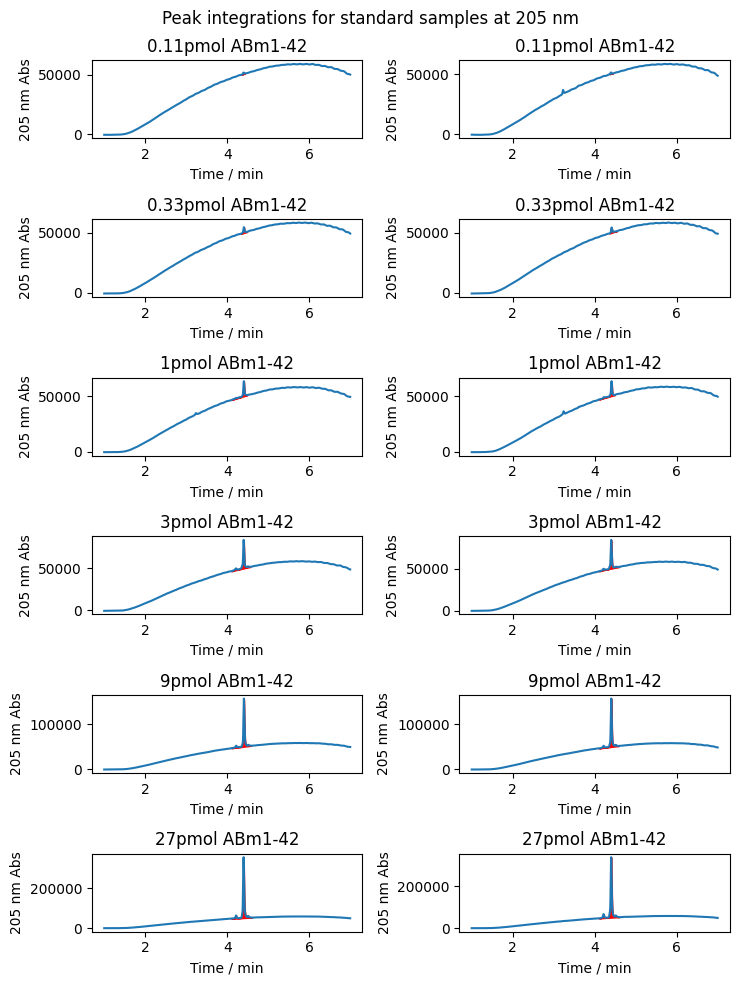

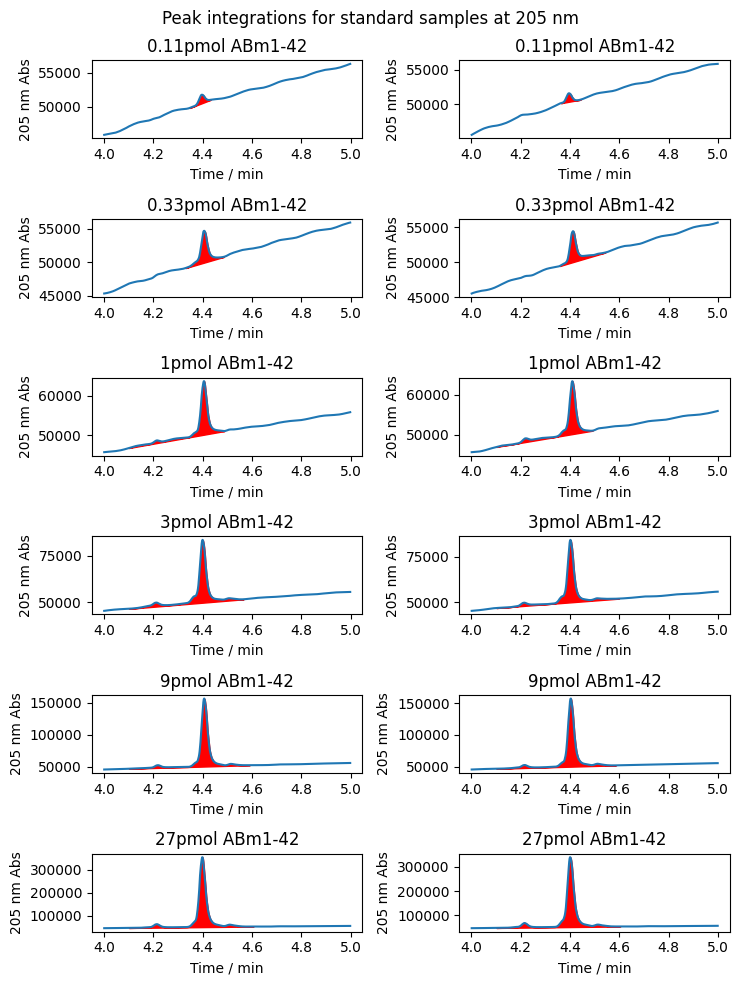

In [25]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for standard samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for standards at zoom'+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

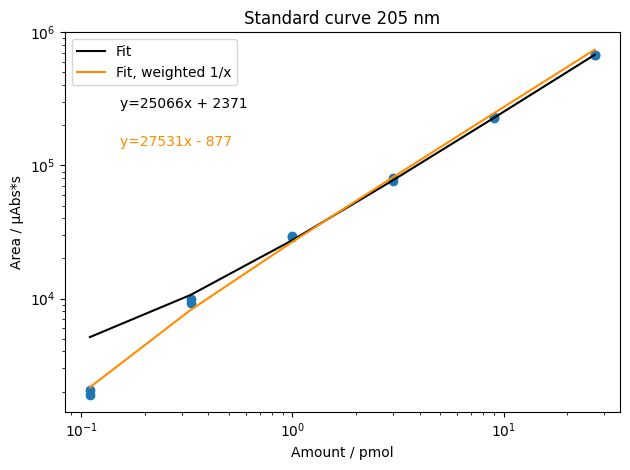

In [26]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x + '+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x - '+str(abs(round(fit_w[0]))),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / µAbs*s')
plt.title('Standard curve 205 nm')
std_curve_eq = fit_w
plt.tight_layout()

plt.savefig('plots/'+project_name+'/205nm standard curve.pdf')

### Controls 

In [27]:
UV.filter(pl.col('Data Filename').str.contains('buffer'))

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A2""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_buffer_001_02.lcd""",null,null,null,null,null,null,null,null
"""F1""","""buffer""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_buffer_nametest_02.lcd""","""Control""",null,null,null,null,null,null,null


In [28]:
UV.filter((pl.col('Data Filename').str.contains('frozen')
              ) | (pl.col('Vial#')==('F1')
         )).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""F1""","""buffer""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_buffer_nametest_02.lcd""","""Control""",null,null,null,null,null,null,null
"""F3""","""frozen monomer 0.82 uM""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_frozen monomer 0.82 uM_nametest_01.lcd""","""Control""",4.325,232499.0,9.821,74787.0,4.1,4.6,null
"""F2""","""frozen monomer 8.2 uM""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_frozen monomer 8.2 uM_nametest_01.lcd""","""Control""",4.347,588870.0,25.008,174828.0,4.1,4.6,null


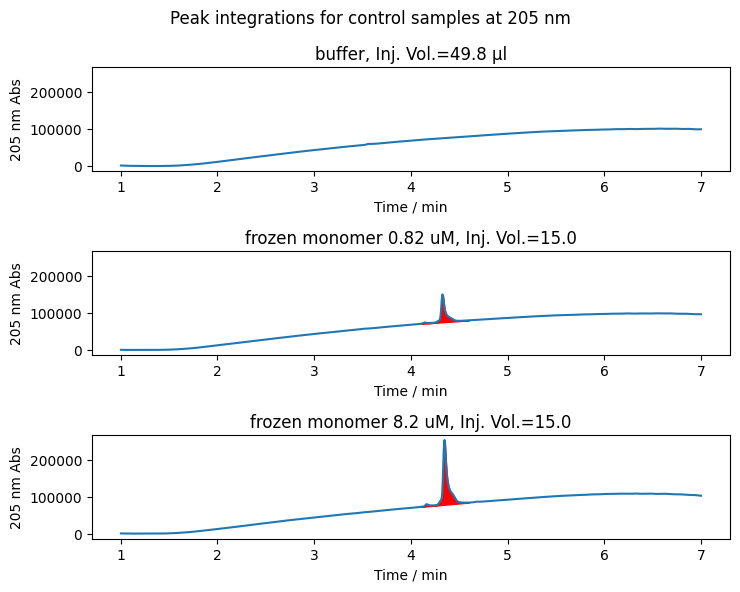

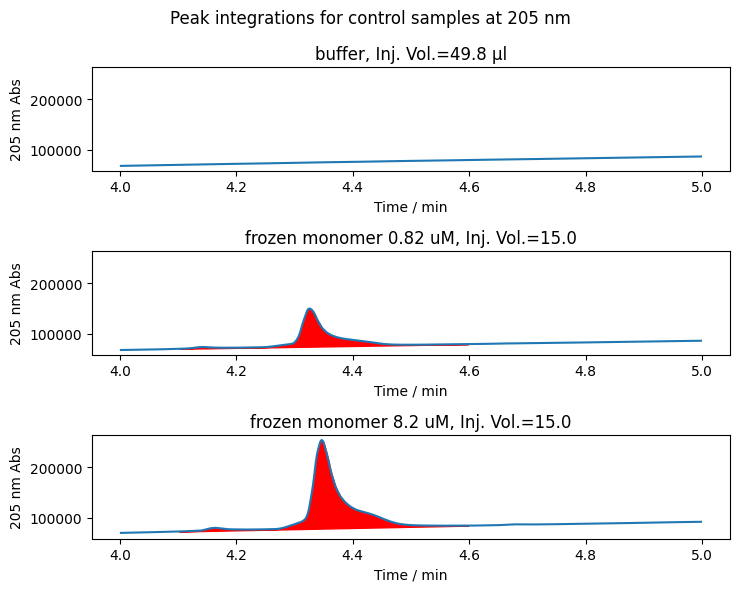

In [29]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(3,figsize=(7.5,6),sharey=True)

    for n,name in enumerate(UV.filter((pl.col('Data Filename').str.contains('frozen')
              ) | (pl.col('Vial#')==('F1')
         )).sort(by='Sample Name')['Data Filename']):
        if UV.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for control samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205 integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

In [30]:
UV.with_columns(
    pl.col('Conc.')/pl.col('Inj. Volume')
).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.001,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,-0.002333,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.037,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.034778,4412.0,4.357,4.545,0.33
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.332,42814.0,0.115867,11511.0,4.1,4.6,null
"""A2""","""10c2d_2""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""",4.335,30310.0,0.080333,10599.0,4.1,4.6,null
"""A3""","""10c2d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_3_25_14.lcd""","""Unknown""",4.328,88239.0,0.073775,26328.0,4.1,4.6,null
"""A4""","""10c2d_4""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_4_26_15.lcd""","""Unknown""",4.337,112714.0,0.094719,34485.0,4.1,4.6,null
"""A5""","""10c2d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_5_45_34.lcd""","""Unknown""",4.33,144122.0,0.121586,37308.0,4.1,4.6,null


In [31]:
UV.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Vial#')!="-1"
).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.332,42814.0,1.738,11511.0,4.1,4.6,null
"""A2""","""10c2d_2""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""",4.335,30310.0,1.205,10599.0,4.1,4.6,null
"""A3""","""10c2d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_3_25_14.lcd""","""Unknown""",4.328,88239.0,3.674,26328.0,4.1,4.6,null
"""A4""","""10c2d_4""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_4_26_15.lcd""","""Unknown""",4.337,112714.0,4.717,34485.0,4.1,4.6,null
"""A5""","""10c2d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_5_45_34.lcd""","""Unknown""",4.33,144122.0,6.055,37308.0,4.1,4.6,null
"""A11""","""10c2d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_B_58_48.lcd""","""Unknown""",null,null,null,null,null,null,null
"""A6""","""10c7d_1""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_1_11_04.lcd""","""Unknown""",4.338,50115.0,2.049,16713.0,4.1,4.6,null
"""A7""","""10c7d_2""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_2_12_05.lcd""","""Unknown""",4.328,79102.0,3.285,23368.0,4.1,4.6,null
"""A8""","""10c7d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_3_35_24.lcd""","""Unknown""",4.328,45111.0,1.836,14723.0,4.1,4.6,null


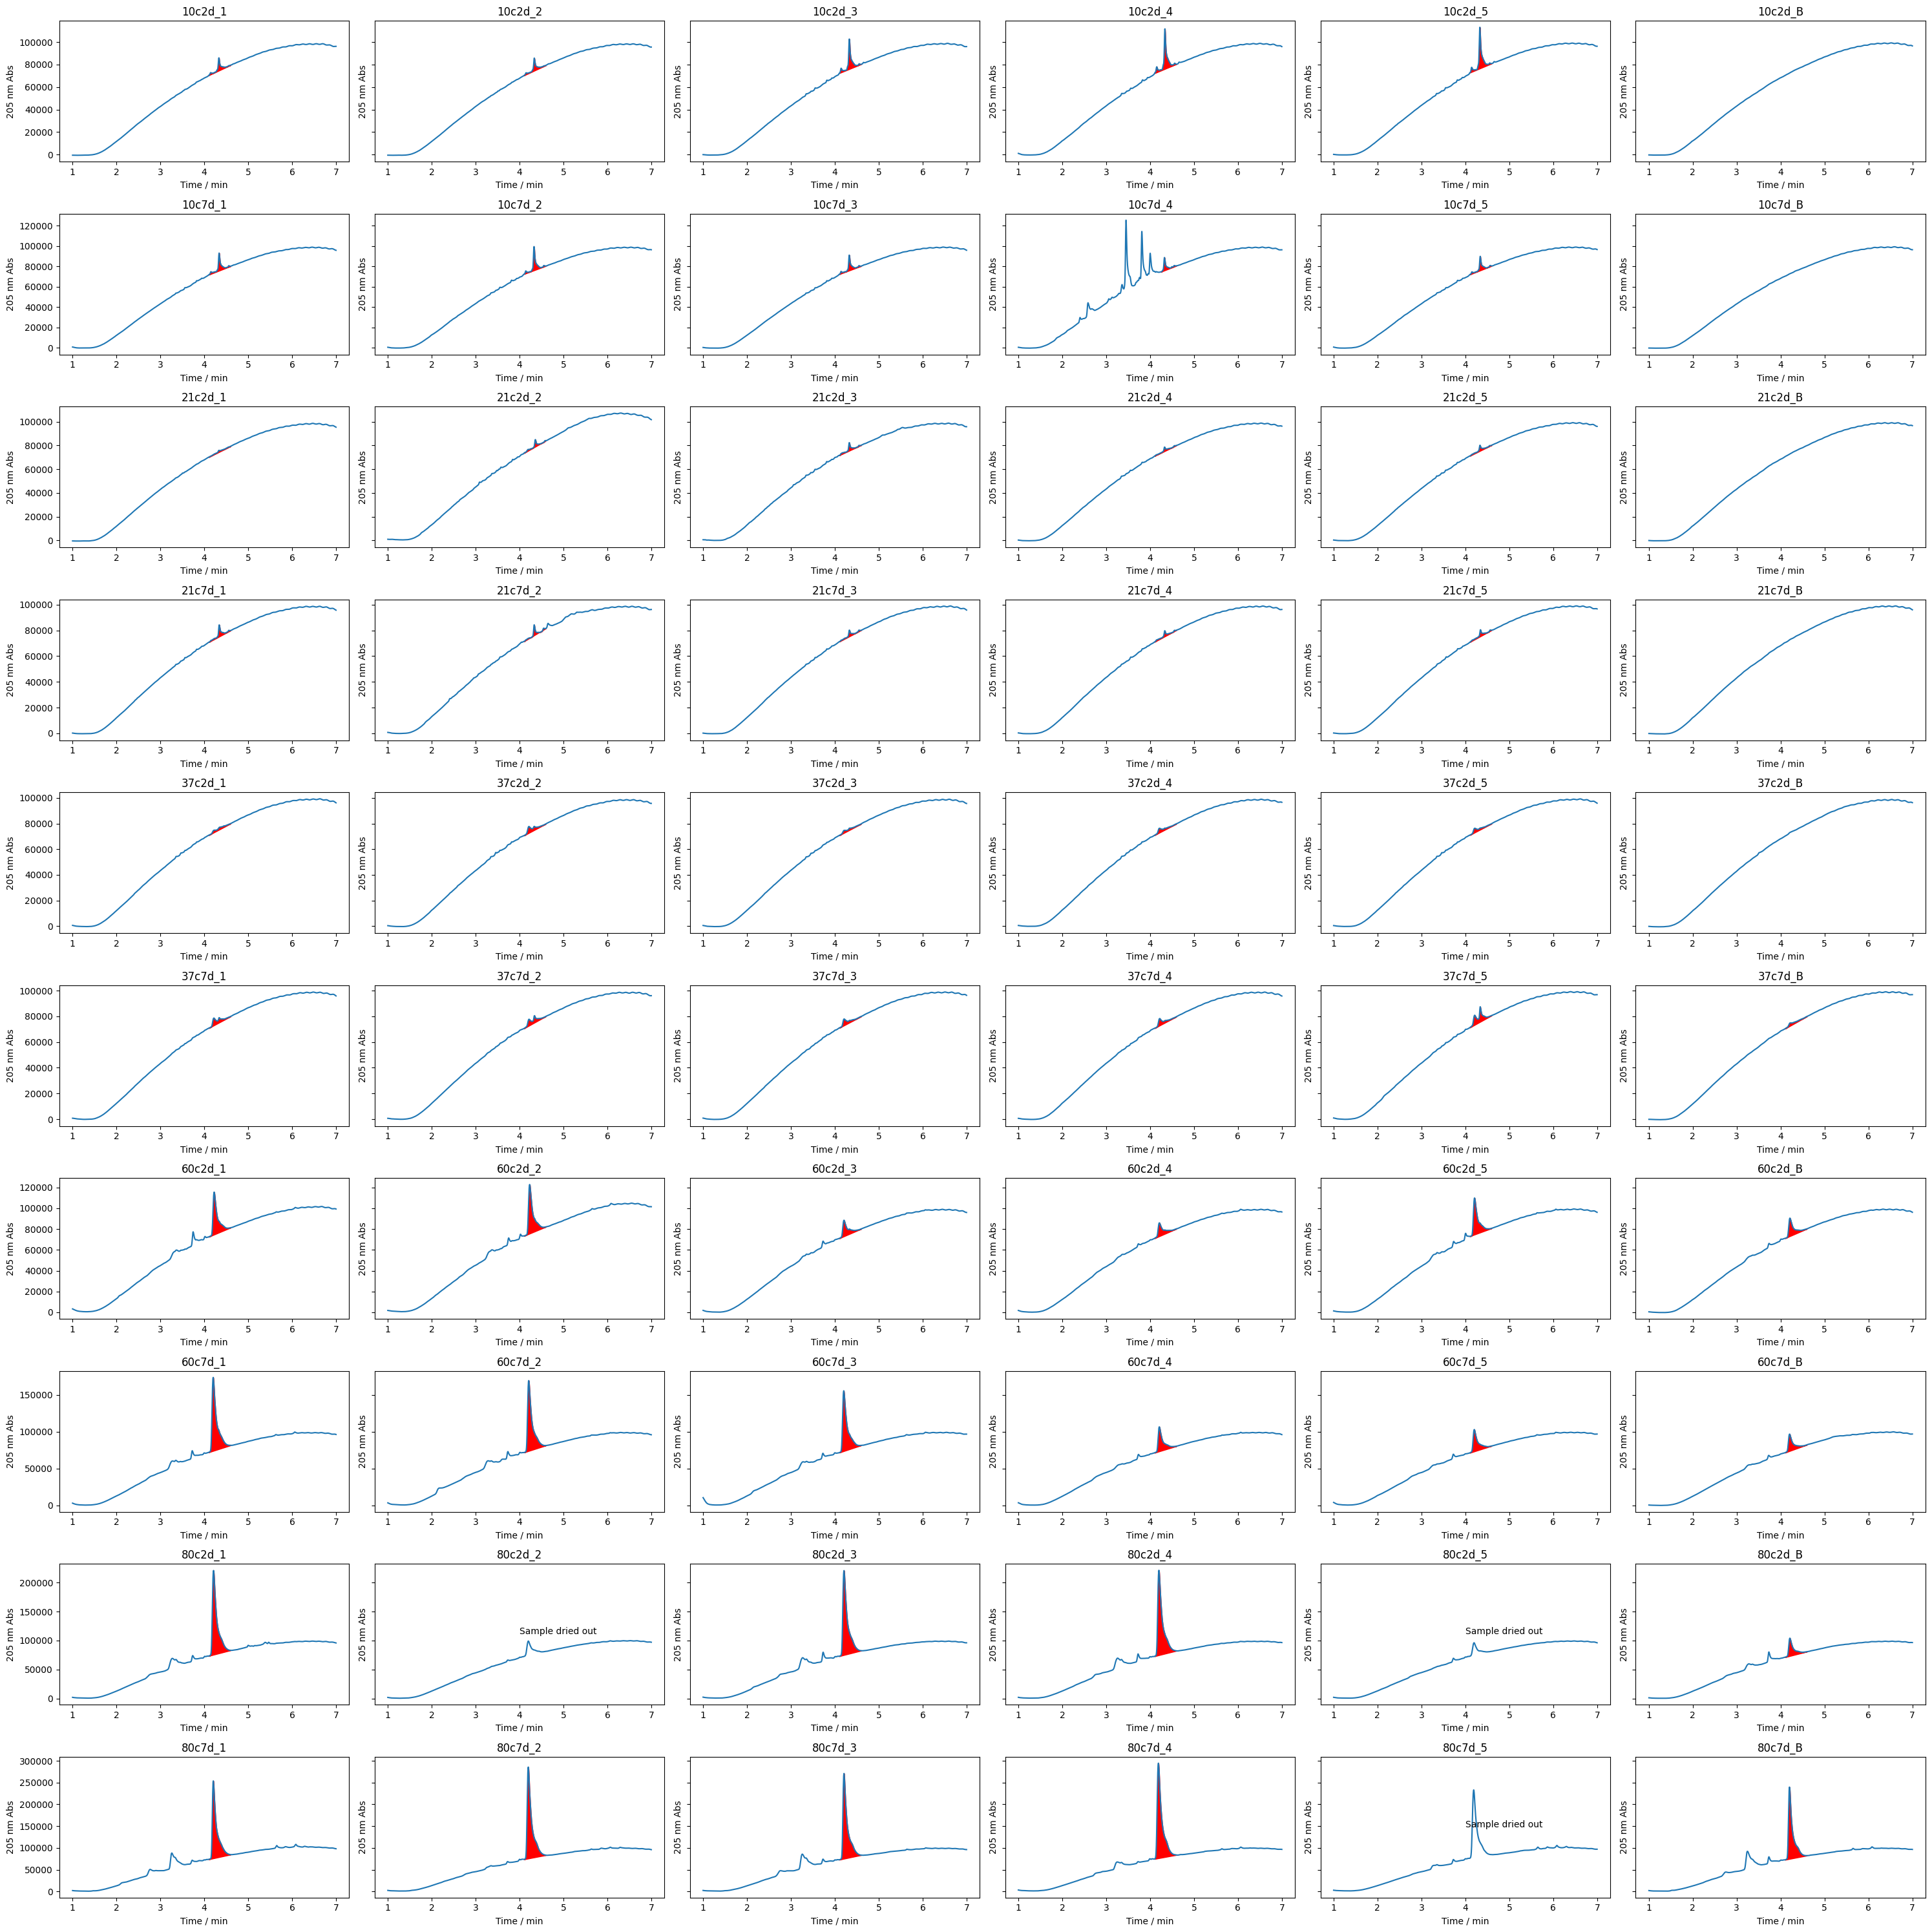

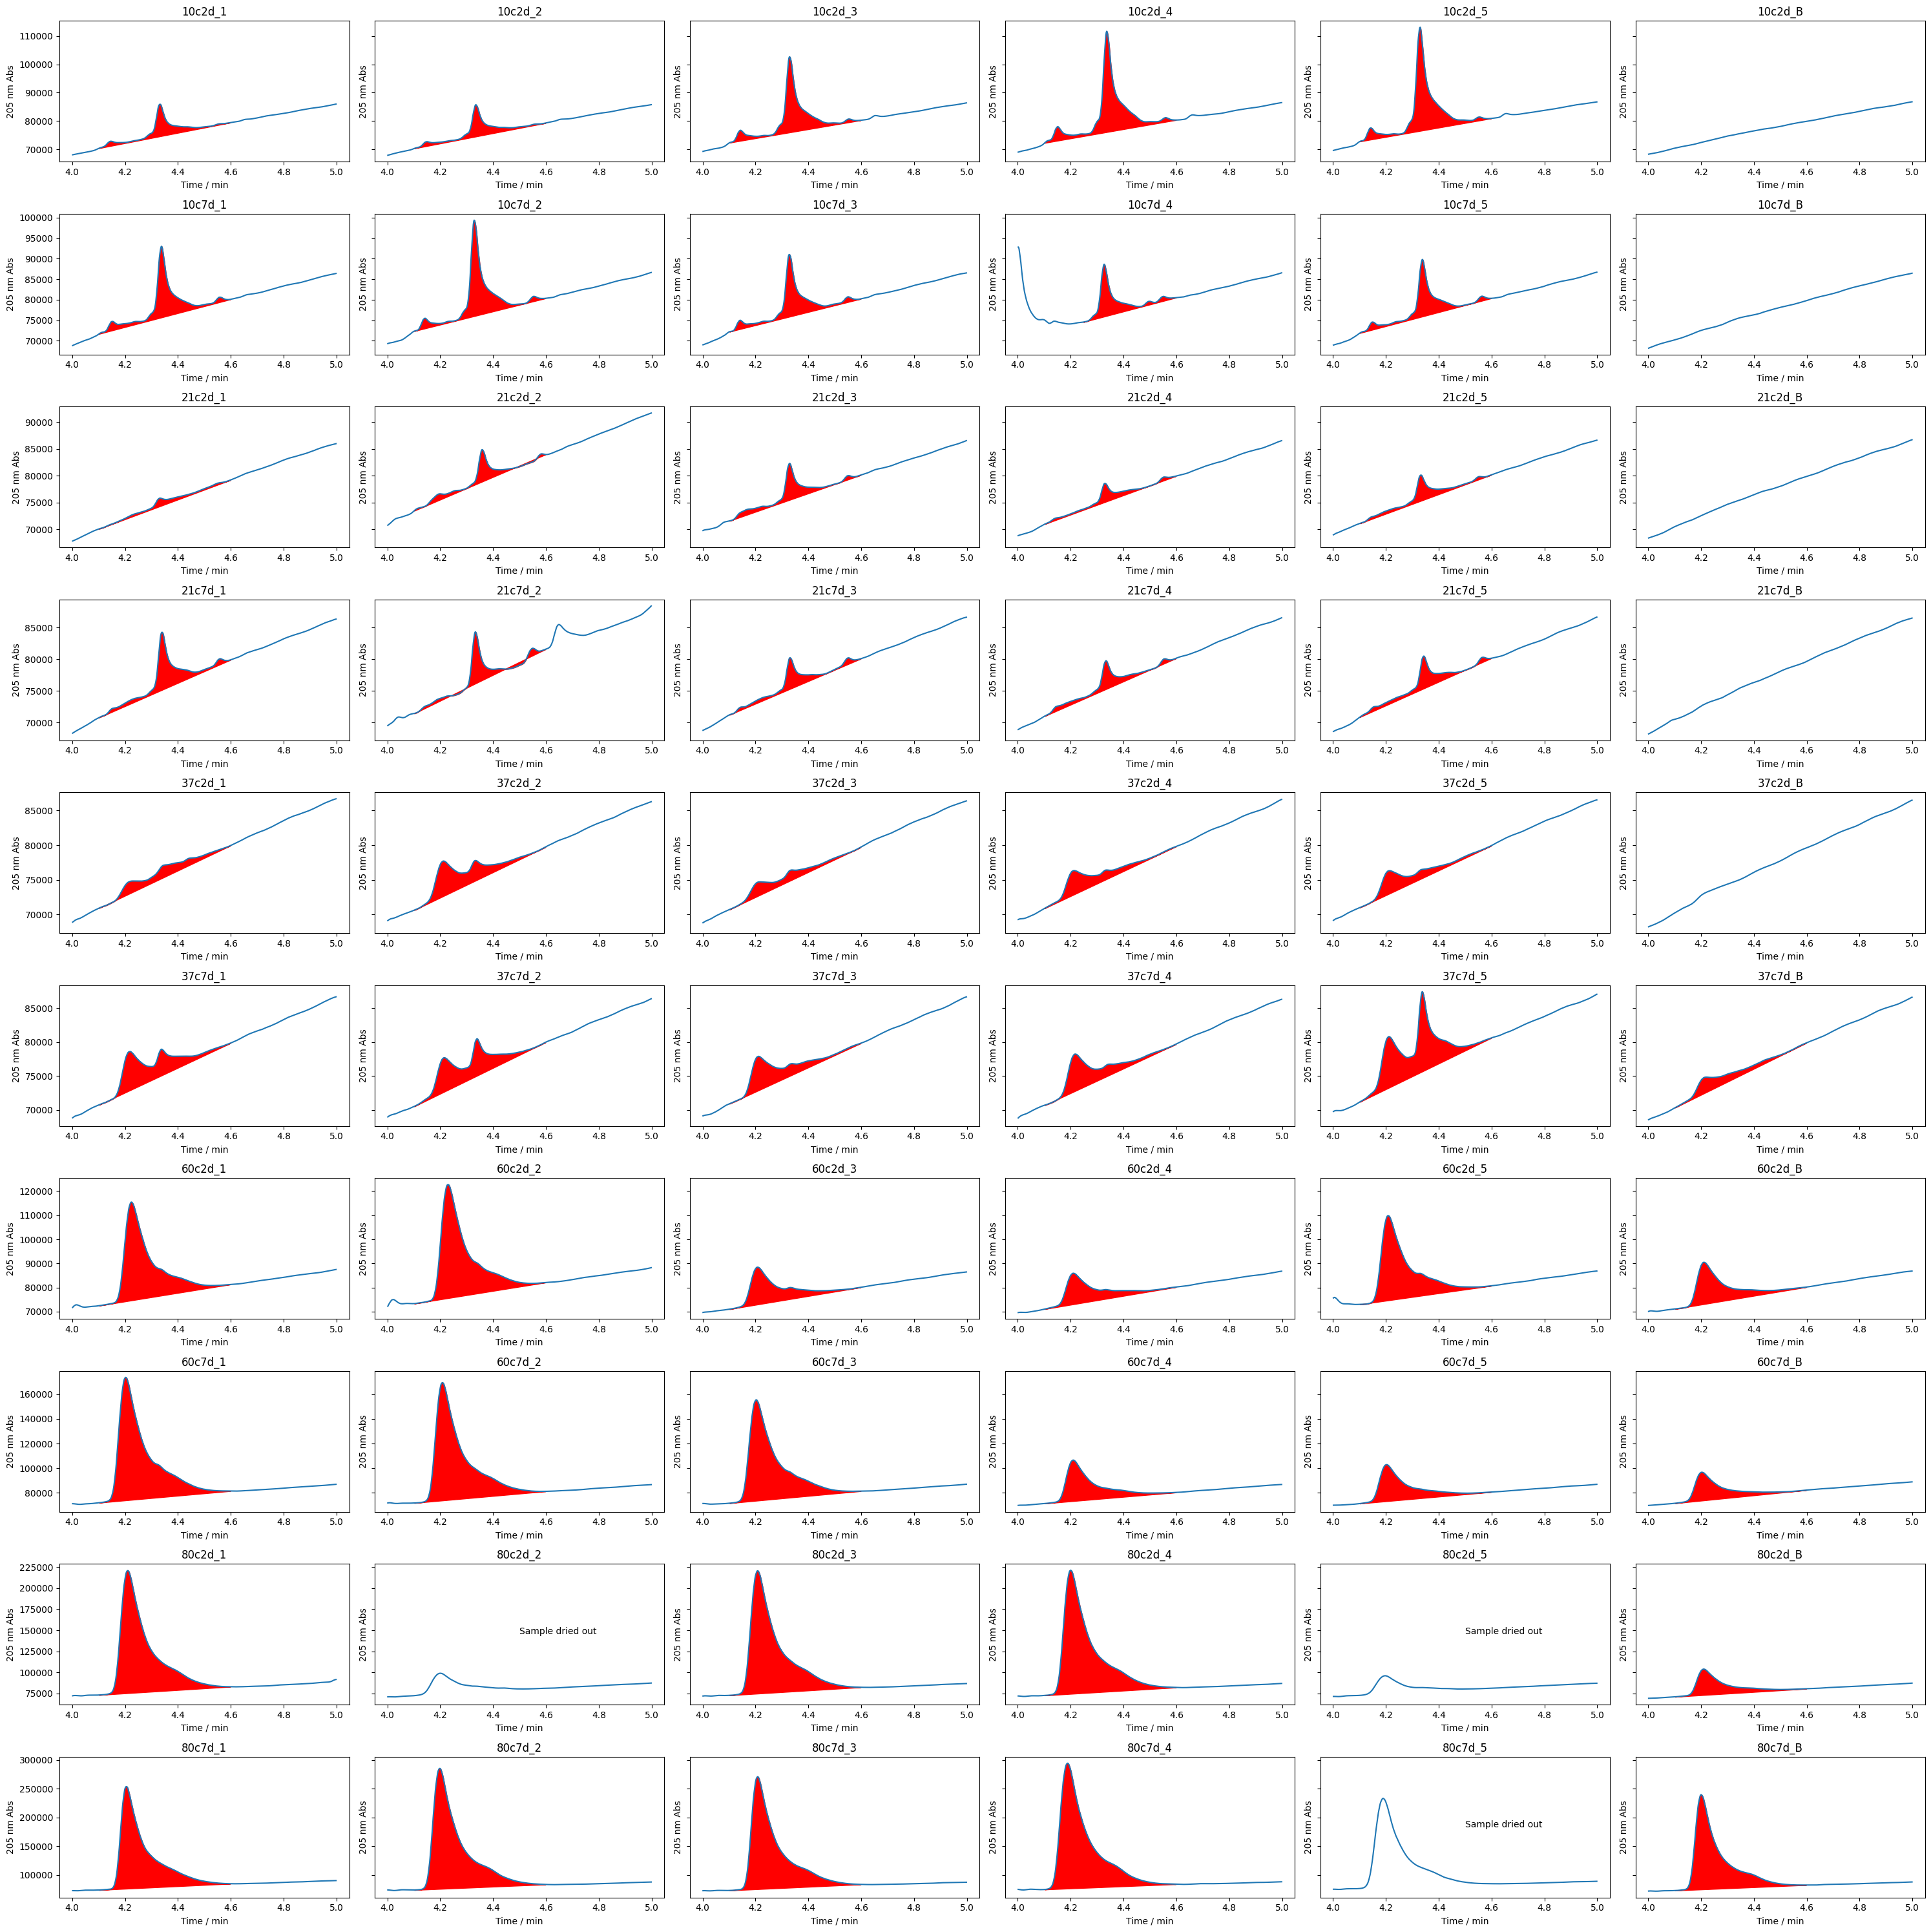

In [32]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
pos = [(i,j) for i in range(10) for j in range(6)]

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(10,6,figsize=(30,30),sharey="row")
    t_df = UV.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Vial#')!="-1"
).sort(by='Sample Name')
    
    for n,name in enumerate(t_df['Data Filename']):
        
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[n]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            

            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            if '_B' not in UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]:
                axs[pos[n]].annotate('Sample dried out',(0.5,0.5), xycoords='axes fraction')
        
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
    #plt.suptitle('Peak integrations for seeded samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for seeded samples -zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


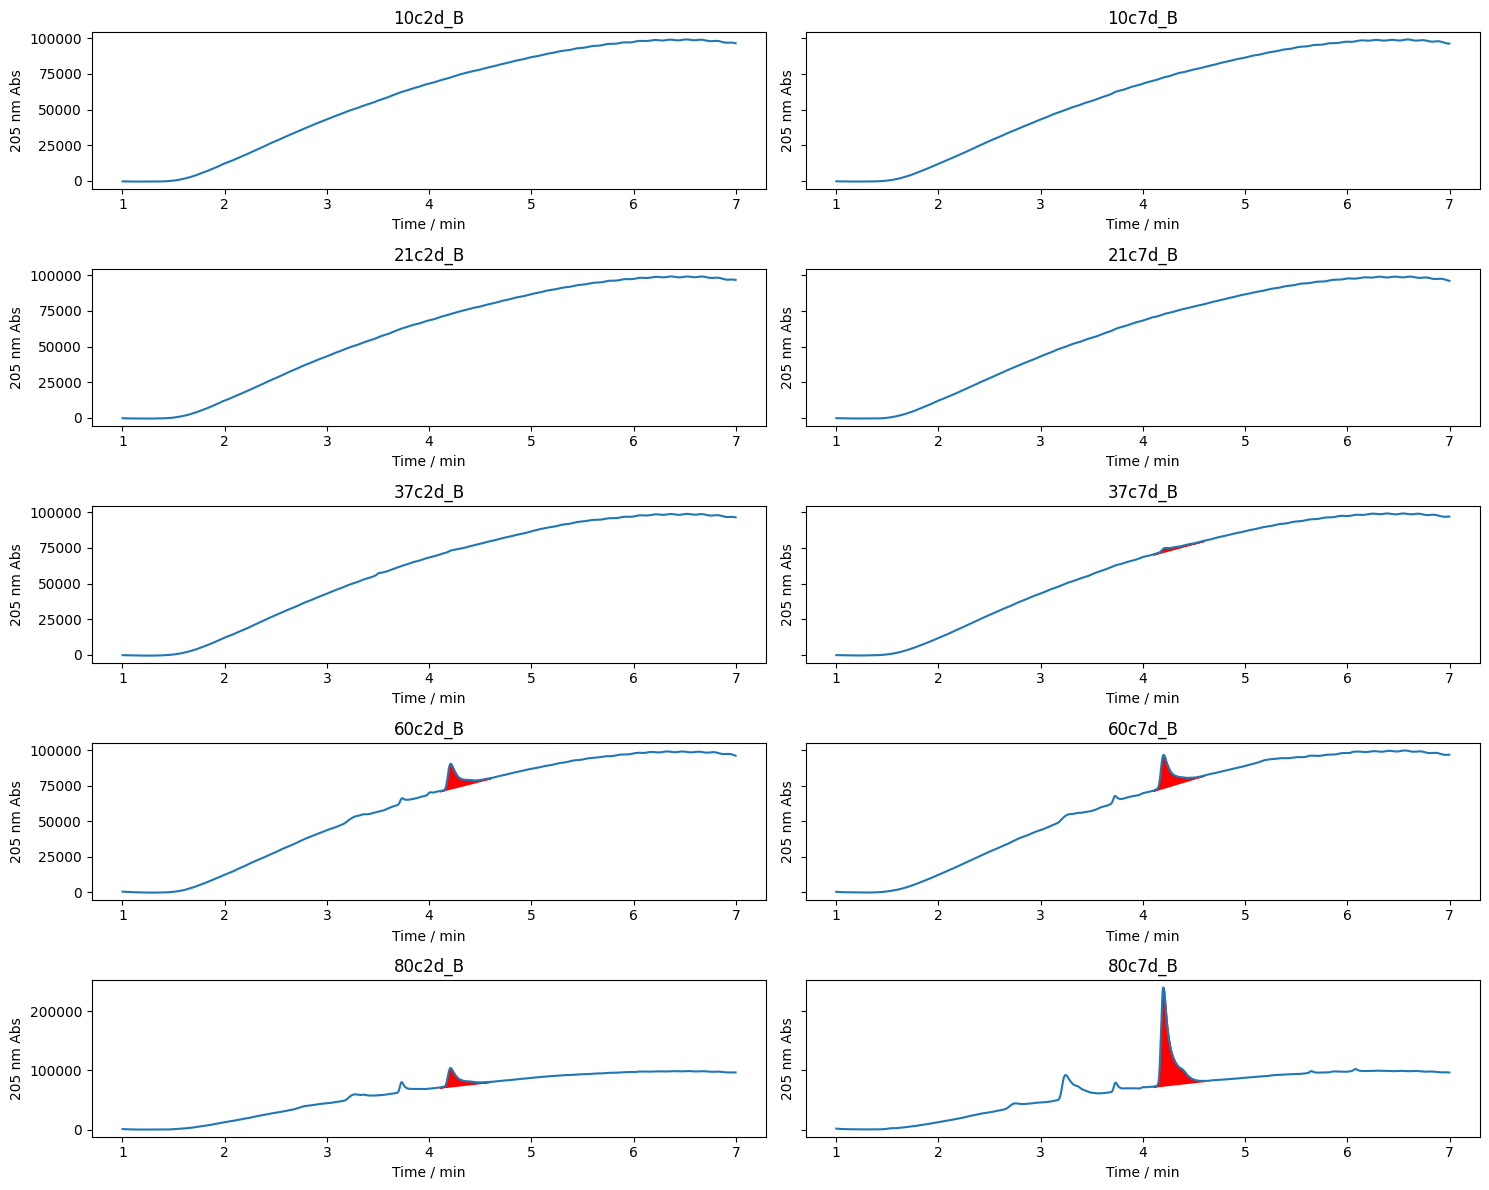

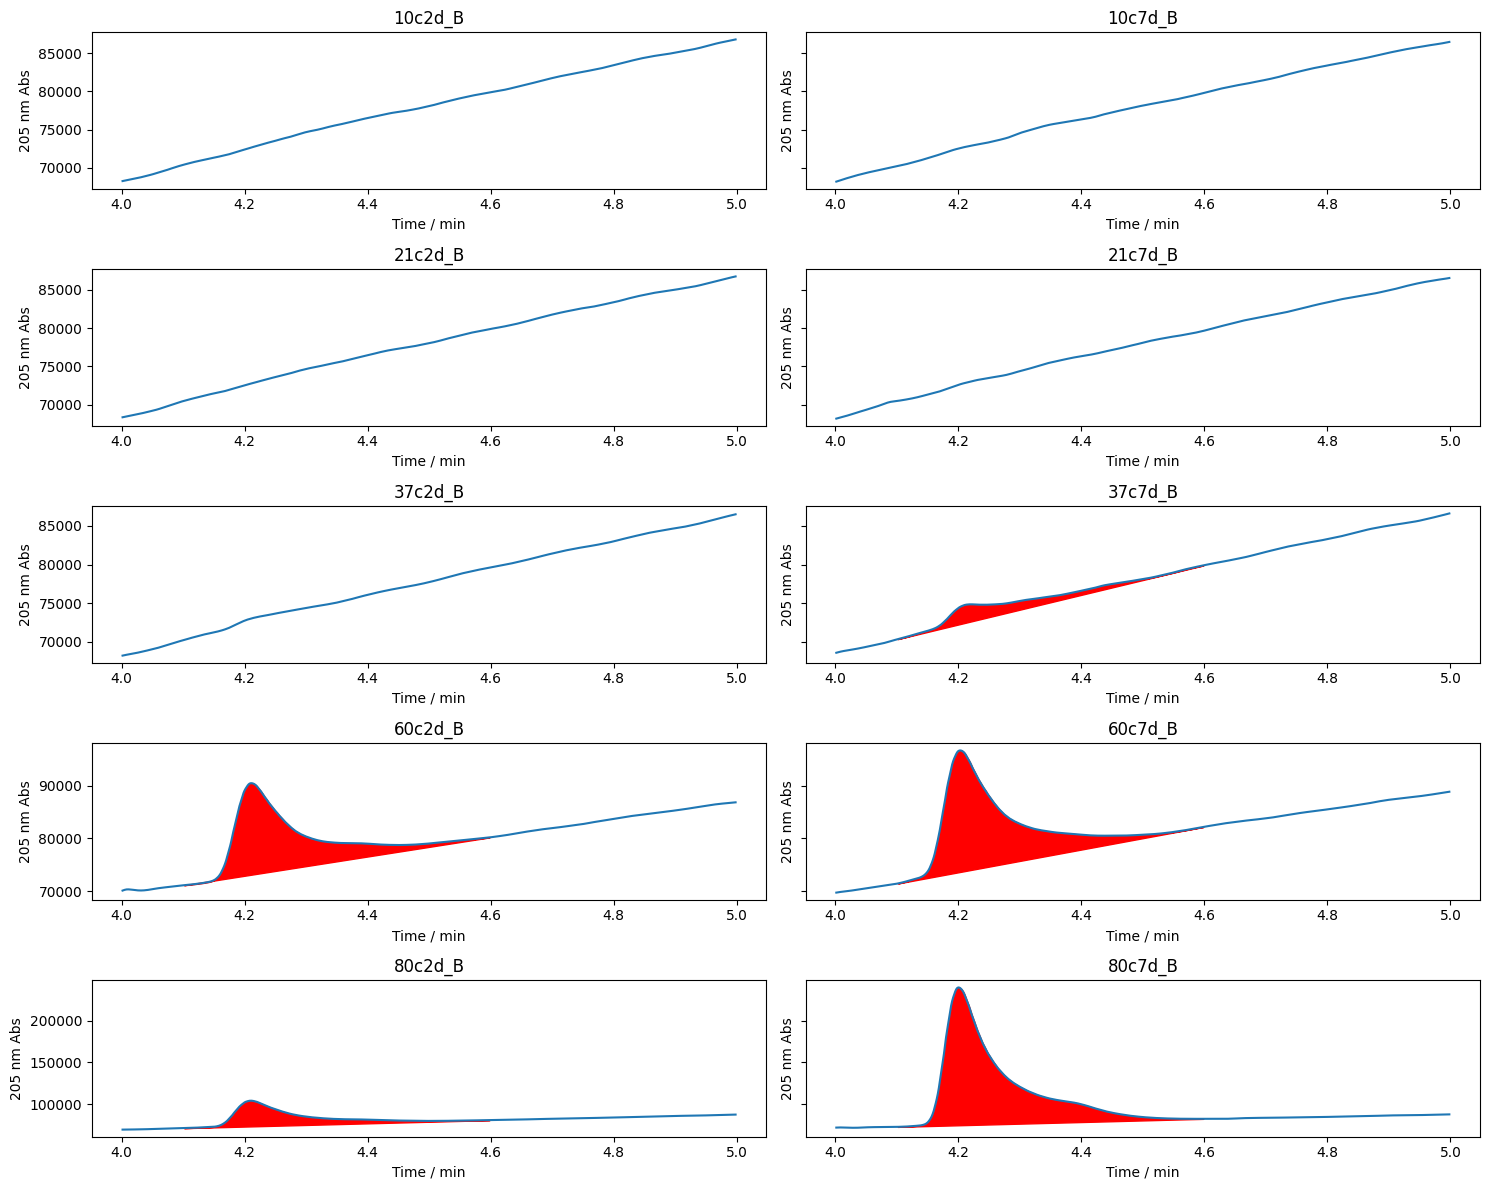

In [33]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
pos = [(i,j) for i in range(5) for j in range(2)]

for zoom in [(1,7),(4,5)]:
    
  #  names=[]
  #  areas=[]
  #  inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(5,2,figsize=(15,12),sharey="row")
    t_df = UV.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Vial#')!="-1"
                 ).filter(pl.col('Sample Name').str.contains("_B")
).sort(by='Sample Name')
    
    for n,name in enumerate(t_df['Data Filename']):
        
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[n]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
        #    areas.append(area*60) # to get it in µAbs*s as in Labsolutions
        #    names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
        #    inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            

            axs[pos[n]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            if '_B' not in UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]:
                axs[pos[n]].annotate('Sample dried out',(0.5,0.5), xycoords='axes fraction')
        
            axs[pos[n]].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('205 nm Abs')
    #plt.suptitle('Peak integrations for seeded samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for buffers -zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [34]:
amounts_UV= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_UV_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [35]:
amounts_UV.filter(pl.col('Sample Name').str.contains('21c'))

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""21c2d_1""",9127.4937,15.0,0.363372
"""21c2d_2""",21438.15864,49.8,0.810523
"""21c2d_3""",28712.31792,49.8,1.074738
"""21c2d_4""",15192.91086,49.8,0.583682
"""21c2d_5""",21635.793,49.8,0.817702
"""21c7d_1""",38460.6576,49.8,1.42882
"""21c7d_2""",22475.6661,49.8,0.848208
"""21c7d_3""",21442.22904,49.8,0.810671
"""21c7d_4""",20358.59058,49.8,0.771311


In [36]:
concs_UV=amounts_UV.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_UV


Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""10c2d_1""",46960.5297,15.0,1.737555,115.836973
"""10c2d_2""",46766.60544,15.0,1.730511,115.367388
"""10c2d_3""",108984.90312,49.8,3.990422,80.128961
"""10c2d_4""",148534.20684,49.8,5.426944,108.974775
"""10c2d_5""",147568.32126,49.8,5.391861,108.270293
"""10c7d_1""",69971.5962,49.8,2.573369,51.674084
"""10c7d_2""",86976.60252,49.8,3.19103,64.076913
"""10c7d_3""",60872.70606,49.8,2.242877,45.037686
"""10c7d_4""",43151.82747,49.8,1.599214,32.112727


In [37]:
corr_factor = (820/
concs_UV.filter(pl.col('Sample Name')=="frozen monomer 0.82 uM"
                )['Conc. (nM)'][0])
corr_factor

1.3434298543726035

In [38]:
concs_UV=concs_UV.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

In [39]:
concs_UV.filter(pl.col('Sample Name').str.contains('_B'))
                                    

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM),Corr. Conc. (nM)
str,f64,f64,f64,f64,f64
"""37c7d_B""",20078.76066,49.8,0.761147,15.284077,20.533085
"""60c2d_B""",121285.28376,49.8,4.4372,89.100408,119.700148
"""60c7d_B""",160639.083,49.8,5.866621,117.803628,158.260911
"""80c2d_B""",215870.4147,49.8,7.872749,158.087339,212.379251
"""80c7d_B""",1.0634e6,49.8,38.656692,776.238789,1042.822363


In [40]:
concs_UV.filter(~pl.col('Sample Name').str.contains('_B')
                        ).filter(pl.col('Sample Name').str.contains('80c')
                            )['Corr. Conc. (nM)'].to_numpy()

array([1021.30845056, 1033.73151165, 1047.35349958, 1945.85470559,
       1804.70761367, 1640.09936273, 1572.99105193])

In [41]:
concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    )
    # .filter(pl.col('Sample Name').str.contains(temp)
    #                             ).filter(pl.col('Sample Name').str.contains('2d')
    #                                     )['Corr. Conc. (nM)'].to_numpy()[0]

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM),Corr. Conc. (nM)
str,f64,f64,f64,f64,f64
"""37c7d_B""",20078.76066,49.8,0.761147,15.284077,20.533085
"""60c2d_B""",121285.28376,49.8,4.4372,89.100408,119.700148
"""60c7d_B""",160639.083,49.8,5.866621,117.803628,158.260911
"""80c2d_B""",215870.4147,49.8,7.872749,158.087339,212.379251
"""80c7d_B""",1.0634e6,49.8,38.656692,776.238789,1042.822363


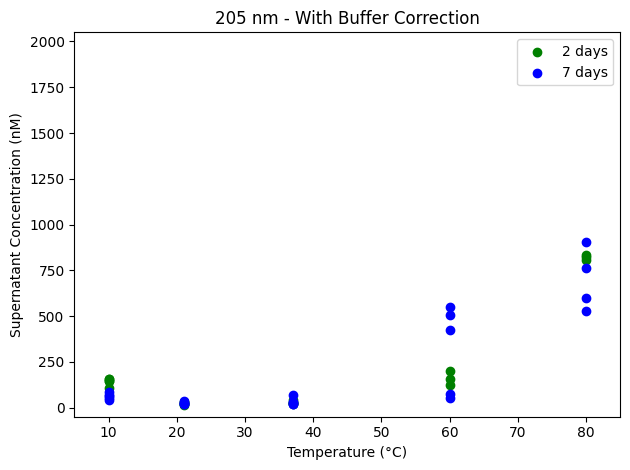

In [42]:
temps=['10','21','37','60','80']
buffer_corr_2days=[]
buffer_corr_7days=[]
temps_2days=[]
temps_7days=[]
for temp in temps:
    y_2d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    buffer_corr_2days.append(y_2d)
    temps_2days.append([int(temp)]*len(y_2d))
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    buffer_corr_7days.append(y_7d)
    temps_7days.append([int(temp)]*len(y_7d))
    
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')

UV_values = pl.DataFrame({'Temp':temps_2days+temps_7days,
                                           'Conc (nM)':buffer_corr_2days+buffer_corr_7days,
                                           'Incubation time (days)':[2]*len(temps_2days)+[7]*len(temps_7days)
                                          })
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.ylim(-50,2050)

plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - With Buffer Correction')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-corr by control samples and buffer.pdf')

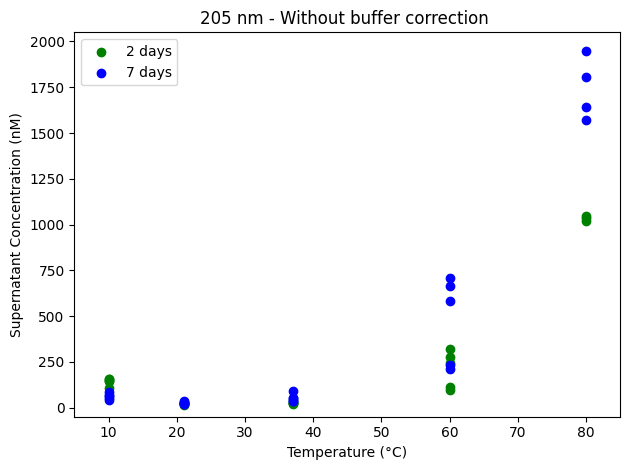

In [43]:
temps=['10','21','37','60','80']
buffer_corr_2days=[]
buffer_corr_7days=[]
temps_2days=[]
temps_7days=[]
for temp in temps:
    y_2d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
 #            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('2d')
 #                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 # if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('2d')
 #                                        ))>0
 # else 0
 #             ][0]
         ) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    buffer_corr_2days.append(y_2d)
    temps_2days.append([int(temp)]*len(y_2d))
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
 #            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('7d')
 #                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 # if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('7d')
 #                                        ))>0
 # else 0
 #             ][0]
         ) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    buffer_corr_7days.append(y_7d)
    temps_7days.append([int(temp)]*len(y_7d))
    
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')

# UV_values = pl.DataFrame({'Temp':temps_2days+temps_7days,
#                                            'Conc (nM)':buffer_corr_2days+buffer_corr_7days,
#                                            'Incubation time (days)':[2]*len(temps_2days)+[7]*len(temps_7days)
#                                           })
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.ylim(-50,2050)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - Without buffer correction ')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-corr by control samples.pdf')

In [44]:
concs_UV['Sample Name'].unique()

Sample Name
str
"""37c7d_2"""
"""80c7d_4"""
"""10c7d_4"""
"""21c7d_3"""
"""37c7d_B"""
"""21c2d_2"""
"""60c7d_B"""
"""21c2d_1"""
"""80c2d_3"""


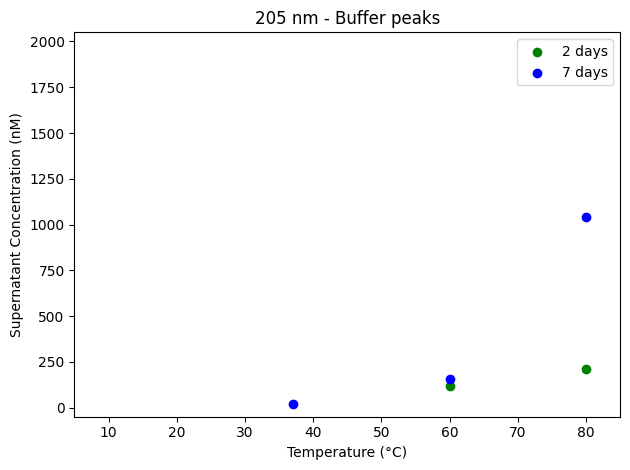

In [45]:
temps=['10','21','37','60','80']
buffer_corr_2days=[]
buffer_corr_7days=[]
temps_2days=[]
temps_7days=[]
for temp in temps:
    y_2d=(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
 #            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('2d')
 #                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 # if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('2d')
 #                                        ))>0
 # else 0
 #             ][0]
         ) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    buffer_corr_2days.append(y_2d)
    temps_2days.append([int(temp)]*len(y_2d))
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
 #            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('7d')
 #                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 # if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
 #                                    ).filter(pl.col('Sample Name').str.contains(temp)
 #                                ).filter(pl.col('Sample Name').str.contains('7d')
 #                                        ))>0
 # else 0
 #             ][0]
         ) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    buffer_corr_7days.append(y_7d)
    temps_7days.append([int(temp)]*len(y_7d))
    
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')

# UV_values = pl.DataFrame({'Temp':temps_2days+temps_7days,
#                                            'Conc (nM)':buffer_corr_2days+buffer_corr_7days,
#                                            'Incubation time (days)':[2]*len(temps_2days)+[7]*len(temps_7days)
#                                           })
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.ylim(-50,2050)

plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - Buffer peaks')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-only buffer.pdf')

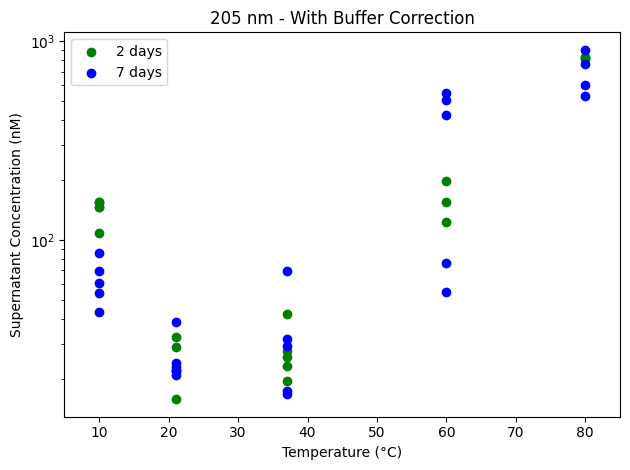

In [46]:
temps=['10','21','37','60','80']
for temp in temps:
    y_2d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    y_2d
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    y_7d
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.legend()
plt.semilogy()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - With Buffer Correction')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-corr by control sample and buffer log.pdf')

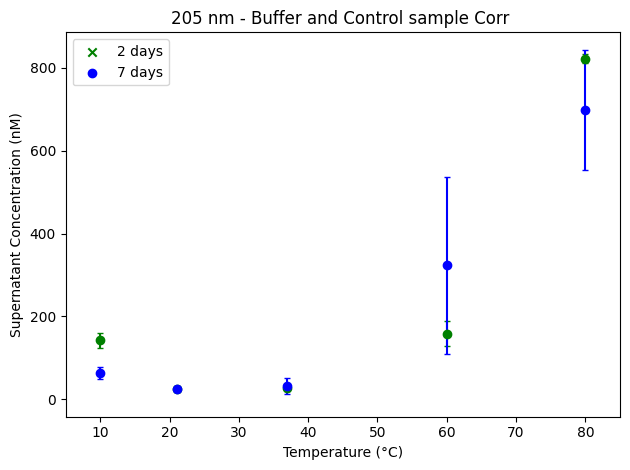

In [47]:
temps=['10','21','37','60','80']
for temp in temps:
    
    y_2d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    y_2d
    
    plt.errorbar([int(temp)],np.mean(y_2d),np.std(y_2d),color='green',marker='o',capsize=2)
    
    y_7d=(concs_UV.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if len(concs_UV.filter(pl.col('Sample Name').str.contains('B')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        ))>0
 else 0
             ][0]) # collect all samples that are not buffer,
                   # subtract the buffer (if a buffer peak exists)
                   # remove negative values
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    y_7d
    plt.errorbar([int(temp)],np.mean(y_7d),np.std(y_7d),color='blue',marker='o',capsize=2)
plt.scatter(0,0,color='green',label='2 days',marker='x')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - Buffer and Control sample Corr ')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm means-corr by control sample and buffer.pdf')

In [48]:
UV_values

Temp,Conc (nM),Incubation time (days)
list[i64],list[f64],i64
"[10, 10, … 10]","[155.618848, 154.987993, … 145.453544]",2
"[21, 21, … 21]","[32.544307, 21.865089, … 22.058741]",2
"[37, 37, … 37]","[23.069144, 42.255416, … 25.718504]",2
"[60, 60, 60]","[154.977796, 197.596444, 122.327258]",2
"[80, 80, 80]","[808.9292, 821.352261, 834.974249]",2
"[10, 10, … 10]","[69.420507, 86.082837, … 54.095285]",7
"[21, 21, … 21]","[38.54456, 22.881689, … 24.094175]",7
"[37, 37, … 37]","[29.323128, 31.661098, … 69.907739]",7
"[60, 60, … 60]","[550.1432, 506.940288, … 54.865092]",7


In [49]:
UV_values.explode(['Temp','Conc (nM)']).write_csv('Processed data/'+project_name+'/UV values.csv')

## MS

### Standard curve

In [50]:
stds = MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.367,4.567,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.426,21744.0,0.364,6361.0,4.333,4.567,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.42,66732.0,1.274,19359.0,4.35,4.7,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.426,60146.0,1.141,16968.0,4.35,4.583,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.416,1.308549e6,26.4,369996.0,4.283,4.7,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.417,1.288584e6,25.996,378560.0,4.35,4.7,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.418,154879.0,3.057,44843.0,4.35,4.667,3.0


In [51]:
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""260105 seeded temp sol_none_nametest_01.lcd""","""Control""","""none""","""-1""",4.566,1227.0,…,null,null,4.467,4.65,-0.99,0.52,"""--"""
2,"""260105 seeded temp sol_buffer_nametest_02.lcd""","""Control""","""buffer""","""F1""",4.517,458.0,…,null,null,null,4.617,-7.35,0.09,"""1.371"""
3,"""260105 seeded temp sol_frozen monomer 8.2 uM_nametest_01.lcd""","""Control""","""frozen monomer 8.2 uM""","""F2""",4.368,2.032677e6,…,null,null,4.283,4.7,0.84,487.73,"""1.995"""
4,"""260105 seeded temp sol_frozen monomer 0.82 uM_nametest_01.lcd""","""Control""","""frozen monomer 0.82 uM""","""F3""",4.347,880465.0,…,null,null,4.25,4.783,1.24,143.19,"""1.891"""
5,"""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""","""10c2d_1""","""A1""",4.351,139753.0,…,null,null,4.283,4.783,1.08,25.57,"""1.867"""
6,"""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""","""10c2d_2""","""A2""",4.354,135491.0,…,null,null,4.2,4.633,1.36,19.64,"""1.800"""
7,"""260105 seeded temp sol_21c2d_1_3_04.lcd""","""Unknown""","""21c2d_1""","""B1""",4.351,17959.0,…,null,null,4.283,4.567,1.12,2.56,"""1.838"""
8,"""260105 seeded temp sol_21c2d_2_4_01.lcd""","""Unknown""","""21c2d_2""","""B2""",4.379,79196.0,…,null,null,4.3,4.733,1.83,8.35,"""2.015"""
9,"""260105 seeded temp sol_37c2d_1_1_5_02.lcd""","""Unknown""","""37c2d_B""","""C1""",null,null,…,null,null,null,null,null,null,null


In [52]:
data_MS['240428-std curve_27pmol ABm1-42_001_13.txt_MS-TIC']

Time (min),Absolute Intensity,Relative Intensity
f64,i64,f64
0.5,4331,1.15
0.517,4415,1.18
0.533,4437,1.18
0.55,4411,1.18
0.567,4409,1.18
0.583,4453,1.19
0.6,4596,1.23
0.617,4769,1.27
0.633,4744,1.27


In [53]:
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""final clean""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_final clean_65_55.lcd""","""Unknown""",4.353,398.0,-0.068,63.0,4.317,4.517,null
"""-1""","""none""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_0_47.lcd""","""Unknown""",4.356,2372.0,-0.028,390.0,4.267,4.567,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_none_nametest_01.lcd""","""Control""",4.566,1227.0,-0.052,190.0,4.467,4.65,null
"""A1""","""10c2d_1""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_1_1_02.lcd""","""Unknown""",4.351,139753.0,2.751,30461.0,4.283,4.783,null
"""A10""","""10c7d_5""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_5_46_35.lcd""","""Unknown""",4.357,109924.0,2.148,22095.0,4.117,4.733,null
"""A11""","""10c2d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_B_58_48.lcd""","""Unknown""",4.356,2639.0,-0.023,355.0,null,4.533,null
"""A12""","""10c7d_B""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c7d_B_59_49.lcd""","""Unknown""",4.37,1522.0,-0.046,274.0,null,4.467,null
"""A2""","""10c2d_2""",15.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_2_2_03.lcd""","""Unknown""",4.354,135491.0,2.665,29606.0,4.2,4.633,null
"""A3""","""10c2d_3""",49.8,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant_tmp.lcm""","""260105 seeded temp sol_10c2d_3_25_14.lcd""","""Unknown""",4.351,284176.0,5.673,59123.0,4.267,5.383,null


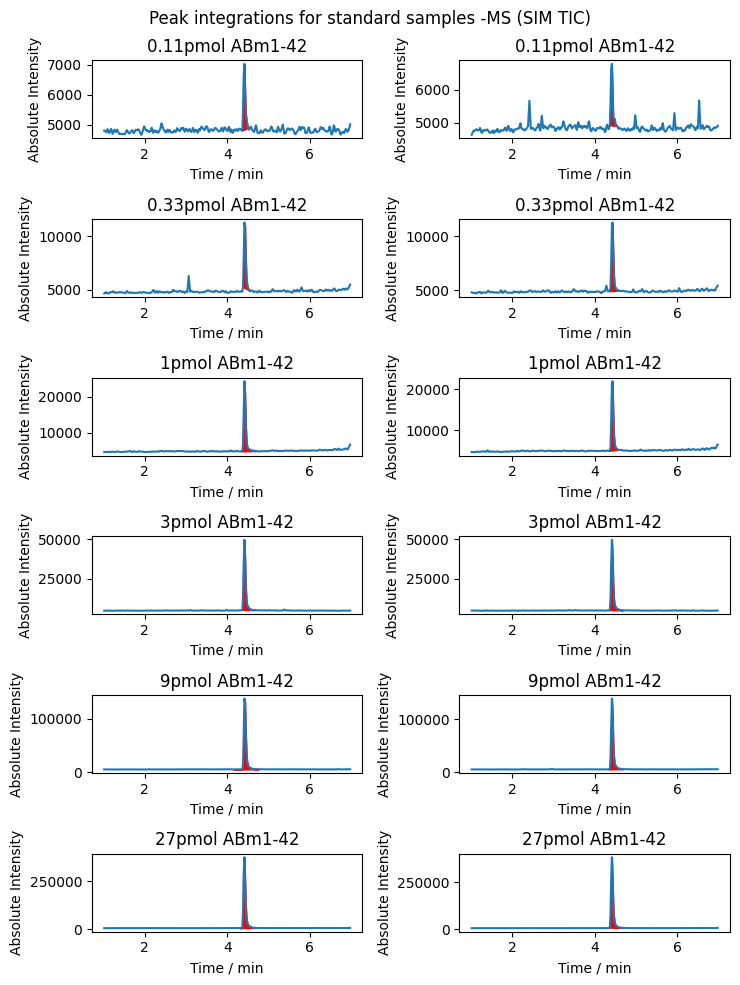

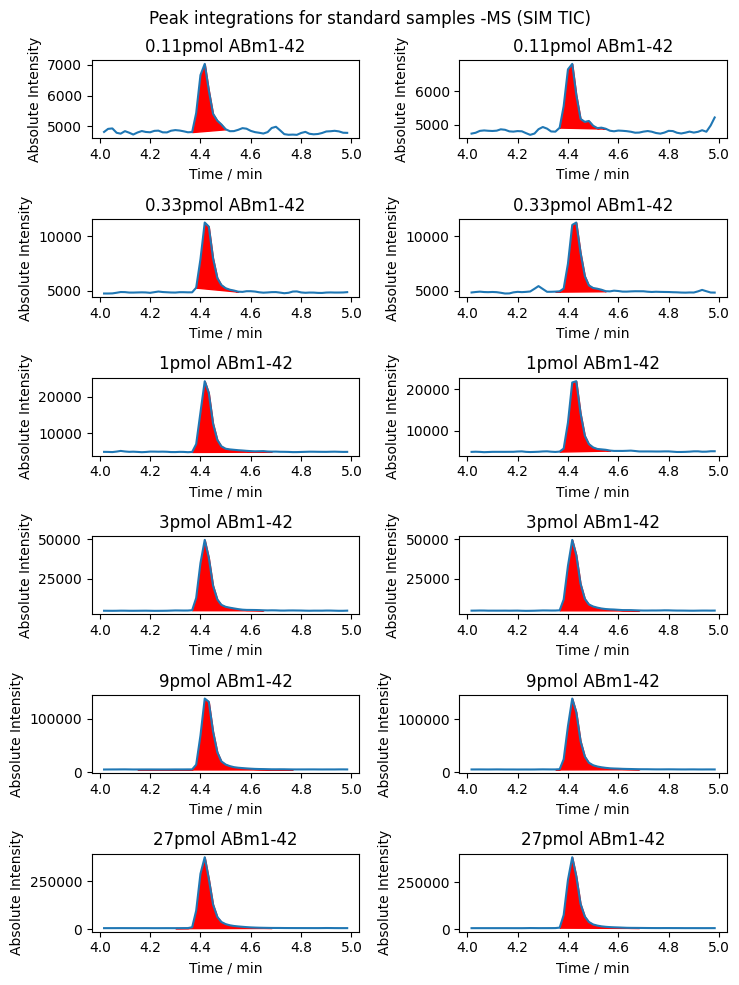

In [54]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in A.U.*s as in Labsolutions?
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for standard samples -MS (SIM TIC)')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for standards at zoom'+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

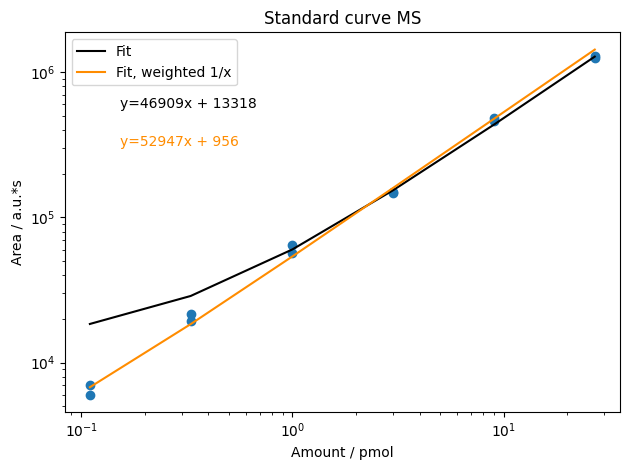

In [55]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x + '+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x + '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / a.u.*s')
plt.title('Standard curve MS')
std_curve_eq = fit_w
plt.tight_layout()

plt.savefig('plots/'+project_name+'/MS standard curve.pdf')

### Controls 

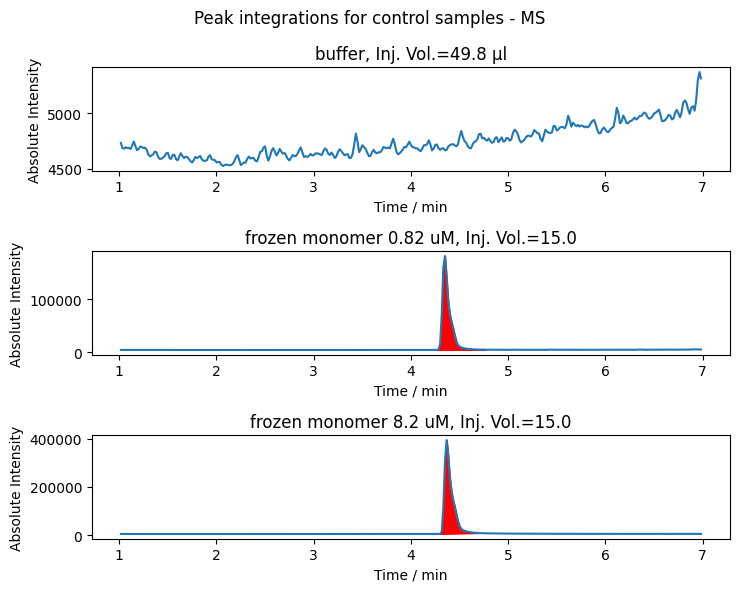

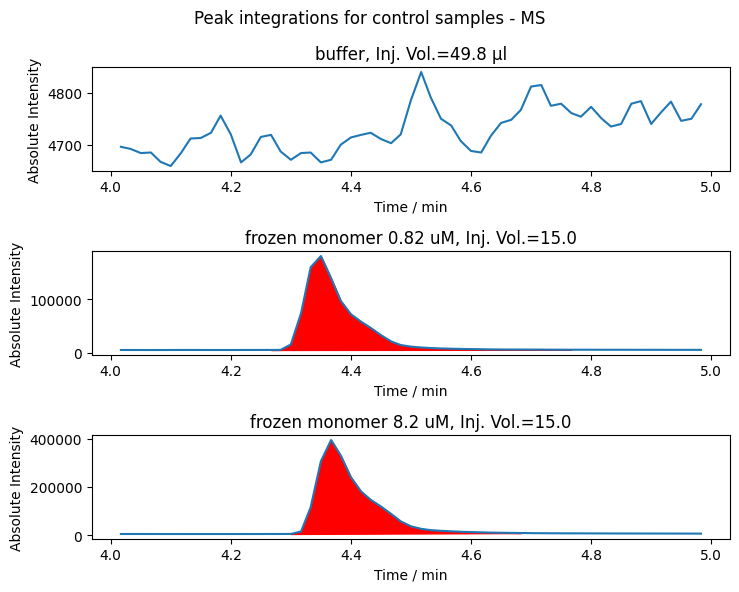

In [56]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(3,figsize=(7.5,6),sharey=False)

    for n,name in enumerate(MS.filter((pl.col('Data Filename').str.contains('frozen')
              ) | (pl.col('Vial#')==('F1')
         )).sort(by='Sample Name')['Data Filename']):
        if MS.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for control samples - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

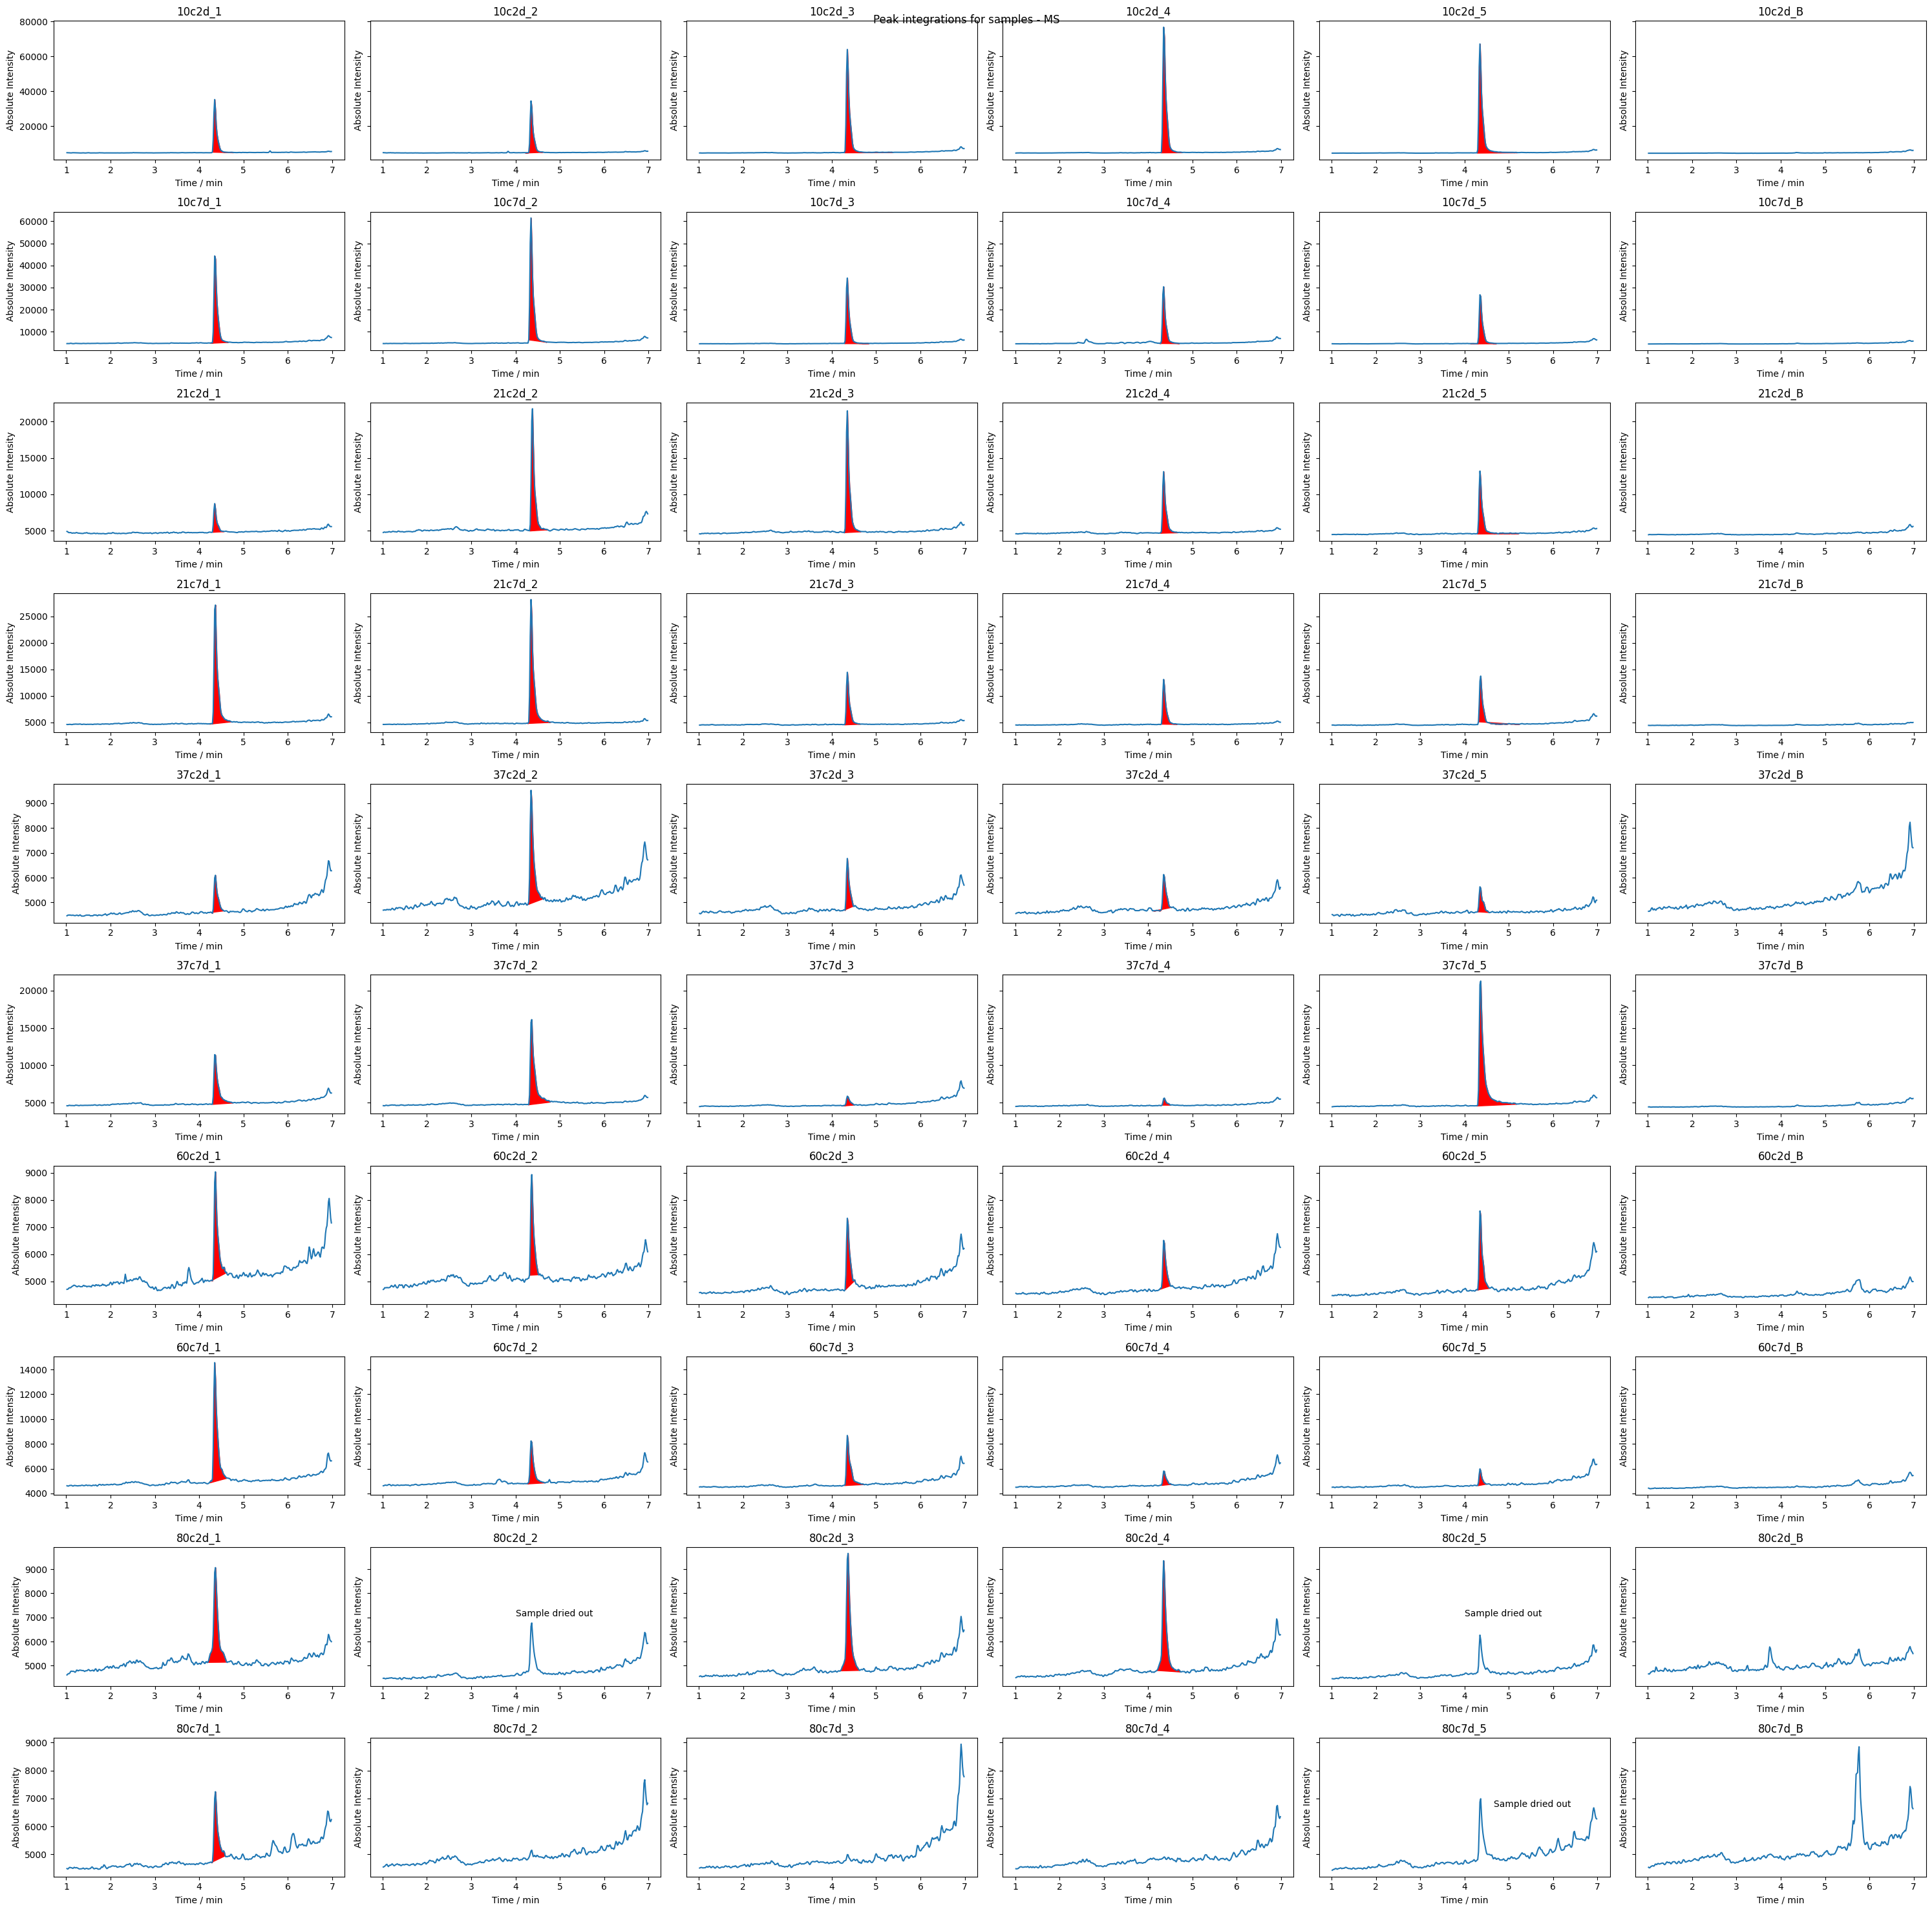

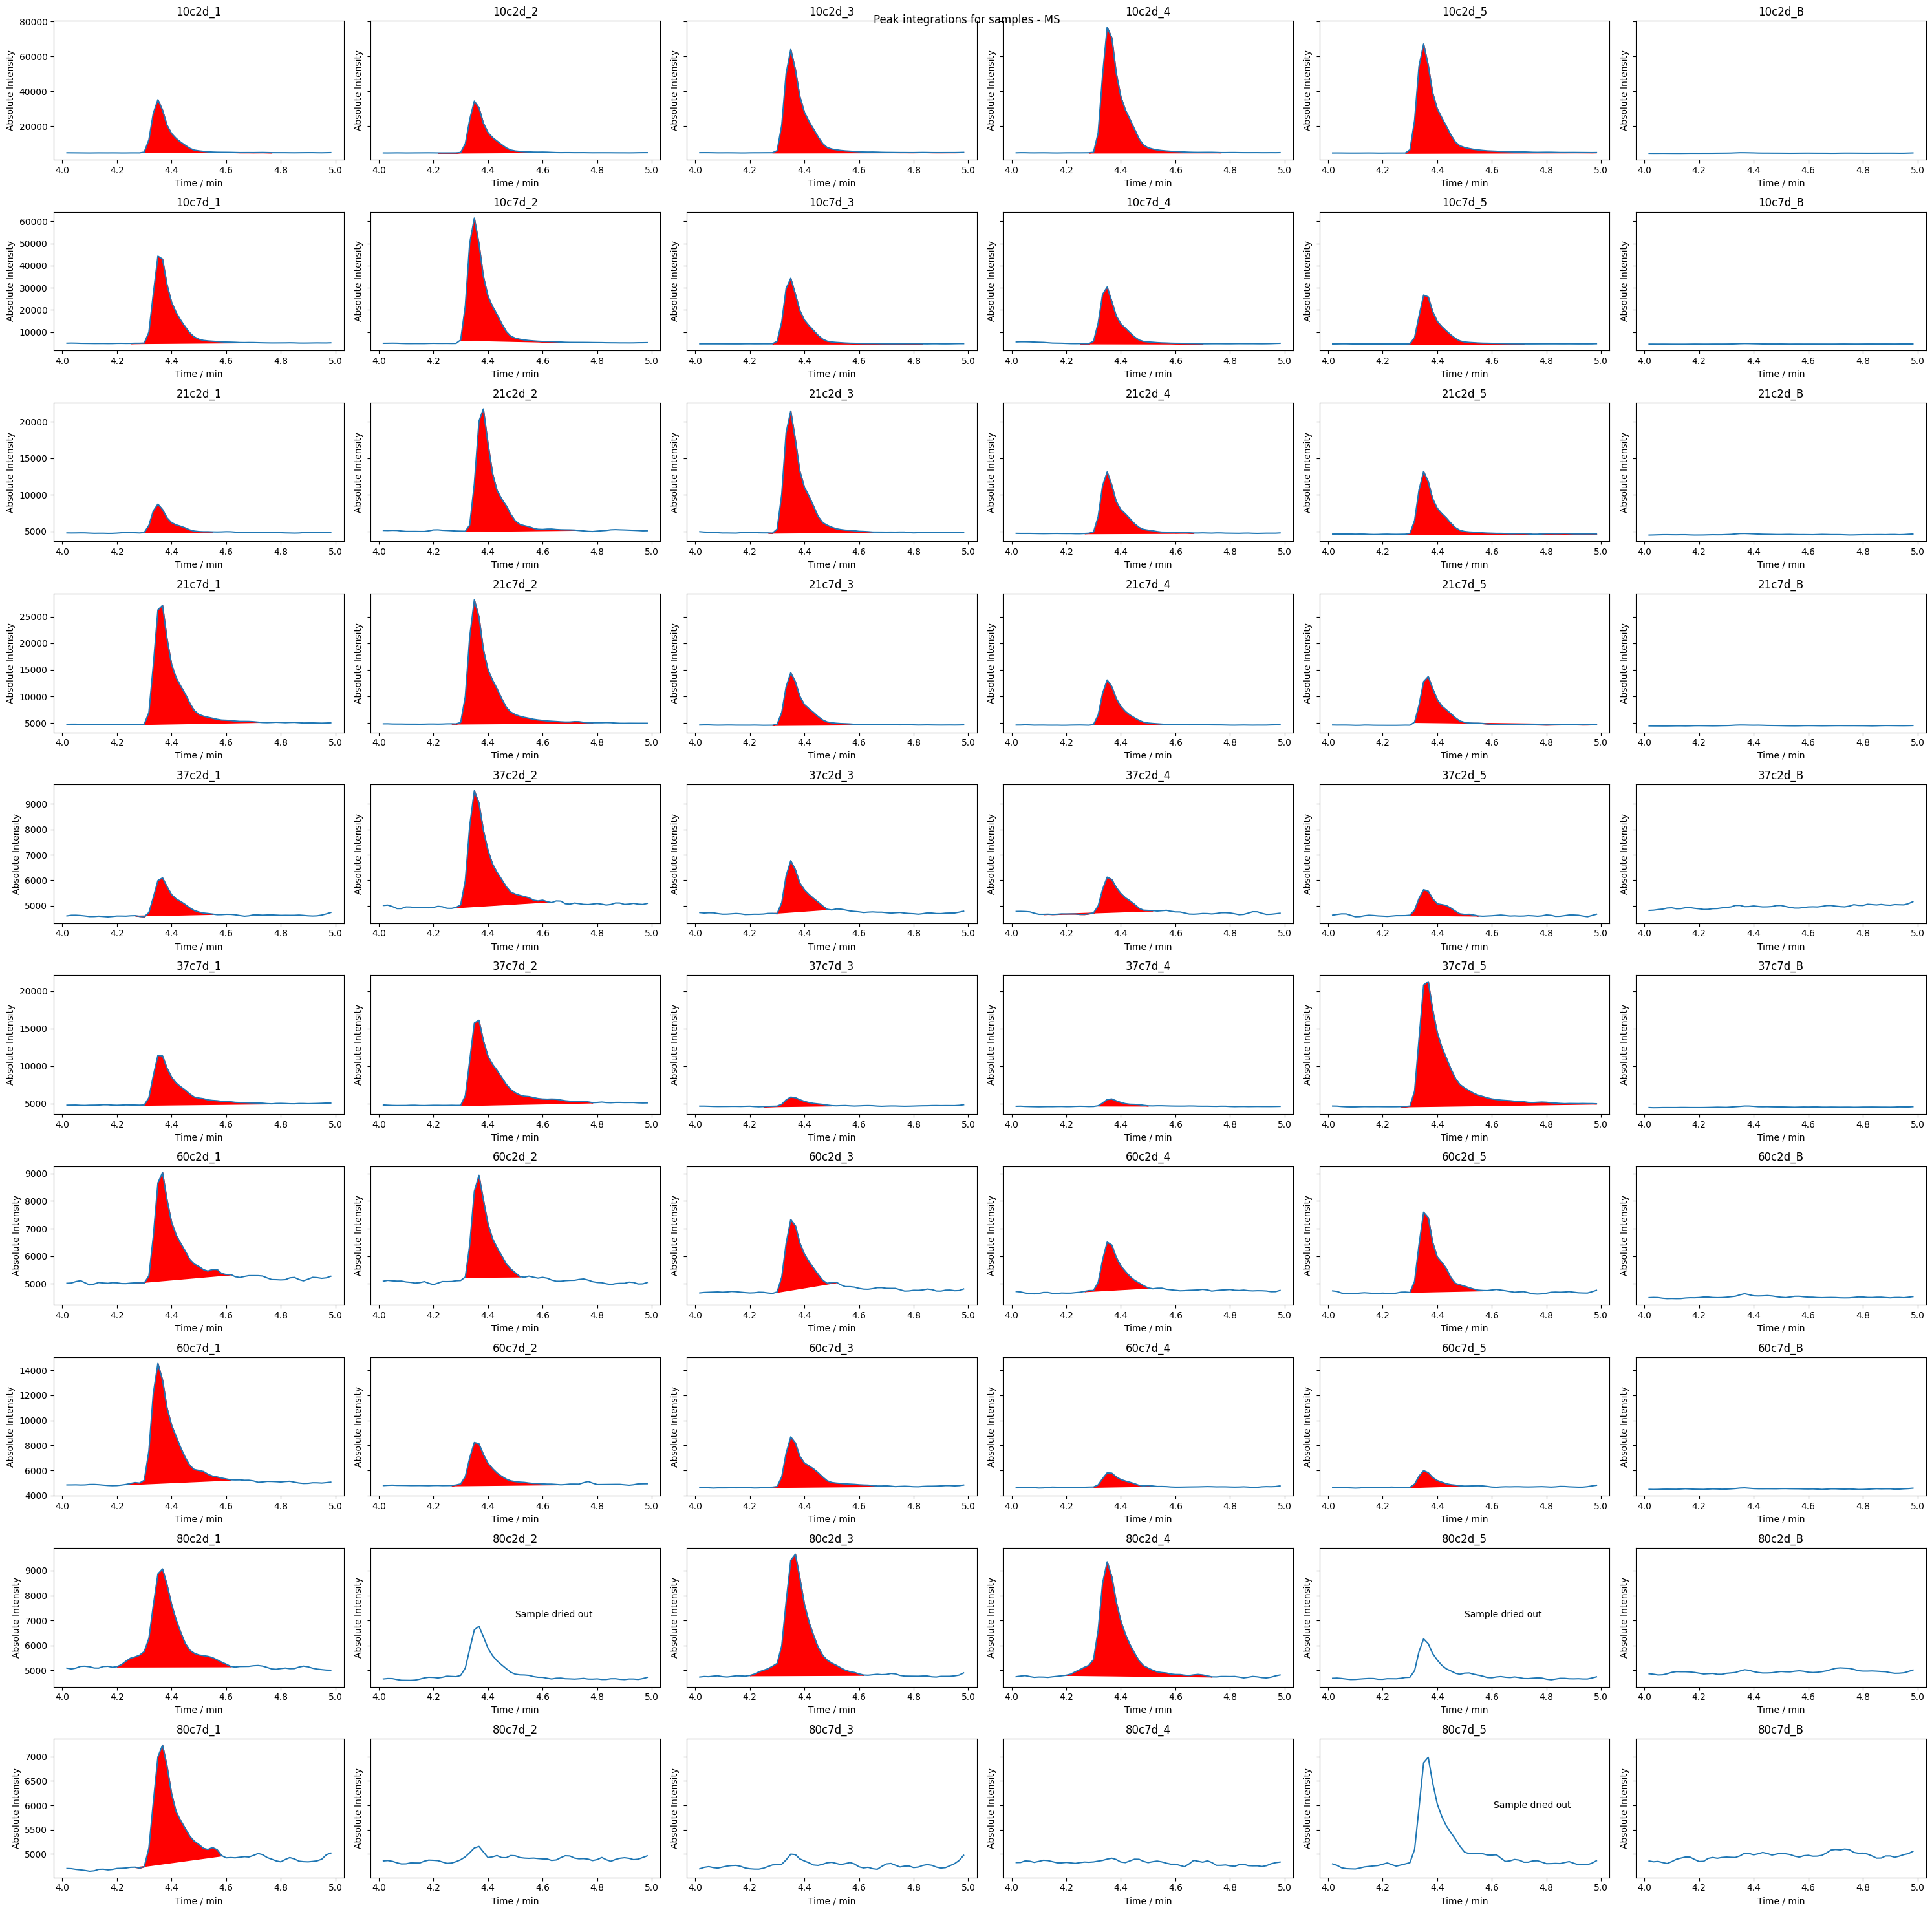

In [57]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
pos = [(i,j) for i in range(10) for j in range(6)]


for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(10,6,figsize=(30,30),sharey='row')
    t_df = MS.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Vial#')!="-1"
).sort(by='Sample Name')
    
    for n,name in enumerate(t_df['Data Filename']):
        
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept

            axs[pos[n]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[n]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in A.U.*s 
            names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[pos[n]].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           

            axs[pos[n]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            
           # if '_B' not in UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]:
                

            
            axs[pos[n]].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[n]].set_xlabel('Time / min')
            axs[pos[n]].set_ylabel('Absolute Intensity')
    axs[8,1].annotate('Sample dried out',(0.5,0.5), xycoords='axes fraction')
    axs[8,4].annotate('Sample dried out',(0.5,0.5), xycoords='axes fraction')
    axs[9,4].annotate('Sample dried out',(0.6,0.5), xycoords='axes fraction')

    plt.suptitle('Peak integrations for samples - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for samples -zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [58]:
amounts_MS= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_MS_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [59]:
amounts_MS

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""10c2d_1""",133147.90905,15.0,2.496663
"""10c2d_2""",133632.774,15.0,2.505821
"""10c2d_3""",281003.7,49.8,5.289175
"""10c2d_4""",353283.99,49.8,6.654313
"""10c2d_5""",317151.864,49.8,5.971895
"""10c7d_1""",194095.89,49.8,3.647771
"""10c7d_2""",253586.04,49.8,4.771345
"""10c7d_3""",138497.238,49.8,2.597694
"""10c7d_4""",119621.85,49.8,2.2412


In [60]:
concs_MS=amounts_MS.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_MS#.filter(pl.col('Sample Name').str.contains('40')
                             #   )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""10c2d_1""",133147.90905,15.0,2.496663,166.44421
"""10c2d_2""",133632.774,15.0,2.505821,167.05471
"""10c2d_3""",281003.7,49.8,5.289175,106.208333
"""10c2d_4""",353283.99,49.8,6.654313,133.620744
"""10c2d_5""",317151.864,49.8,5.971895,119.91758
"""10c7d_1""",194095.89,49.8,3.647771,73.248413
"""10c7d_2""",253586.04,49.8,4.771345,95.810144
"""10c7d_3""",138497.238,49.8,2.597694,52.162539
"""10c7d_4""",119621.85,49.8,2.2412,45.004019


In [61]:
concs_MS.filter(pl.col('Sample Name').str.contains('37c'))

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""37c2d_1""",7628.67474,49.8,0.126016,2.530436
"""37c2d_2""",24463.536,49.8,0.443971,8.915083
"""37c2d_3""",8929.05,49.8,0.150576,3.023606
"""37c2d_4""",6626.814,49.8,0.107094,2.150479
"""37c2d_5""",5379.555,49.8,0.083537,1.677454
"""37c7d_1""",41294.985,49.8,0.761862,15.298436
"""37c7d_2""",73209.51,49.8,1.364623,27.402069
"""37c7d_3""",6321.42,49.8,0.101326,2.034658
"""37c7d_4""",4131.15117,49.8,0.059959,1.203995


In [62]:
corr_factor = (820/
concs_MS.filter(pl.col('Sample Name')=="frozen monomer 0.82 uM"
                )['Conc. (nM)'][0])
corr_factor

0.7453835477312293

In [63]:
concs_MS=concs_MS.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

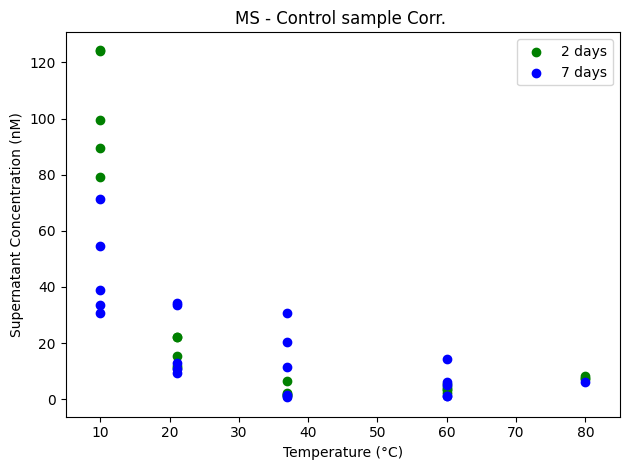

In [64]:
temps=['10','21','37','60','80']
t1=[]
t2=[]
temps_2days=[]
temps_7days=[]
for temp in temps:
    y_2d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    t1.append(y_2d)
    temps_2days.append([int(temp)]*len(y_2d))
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    t2.append(y_7d)
    temps_7days.append([int(temp)]*len(y_7d))
    
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')

MS_values = pl.DataFrame({'Temp':temps_2days+temps_7days,
                                           'Conc (nM)':t1+t2,
                                           'Incubation time (days)':[2]*len(temps_2days)+[7]*len(temps_7days)
                                          })
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - Control sample Corr. ')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates-corr by control samples.pdf')

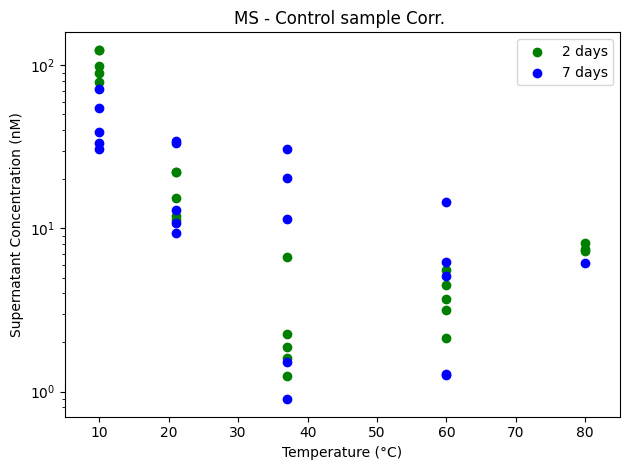

In [65]:
temps=['10','21','37','60','80']
t1=[]
t2=[]
temps_2days=[]
temps_7days=[]
for temp in temps:
    y_2d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    t1.append(y_2d)
    temps_2days.append([int(temp)]*len(y_2d))
    
    plt.scatter([int(temp)]*len(y_2d),y_2d,color='green')
    
    y_7d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    t2.append(y_7d)
    temps_7days.append([int(temp)]*len(y_7d))
    
    plt.scatter([int(temp)]*len(y_7d),y_7d,color='blue')

MS_values = pl.DataFrame({'Temp':temps_2days+temps_7days,
                                           'Conc (nM)':t1+t2,
                                           'Incubation time (days)':[2]*len(temps_2days)+[7]*len(temps_7days)
                                          })
plt.scatter(0,0,color='green',label='2 days')
plt.scatter(0,0,color='blue',label='7 days')
plt.semilogy()
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - Control sample Corr. ')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates-corr by control samples-log.pdf')

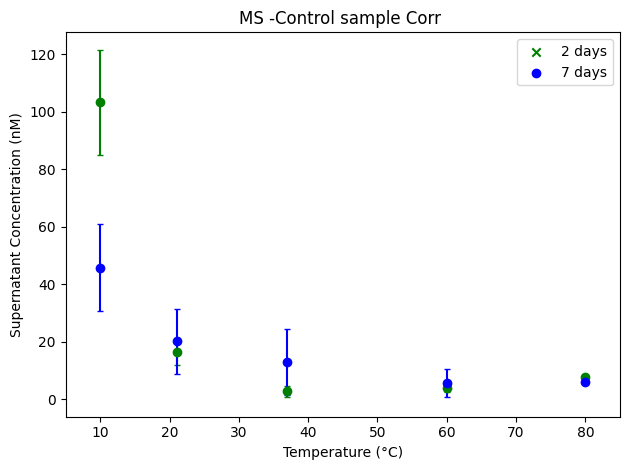

In [66]:
temps=['10','21','37','60','80']
for temp in temps:
    
    y_2d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('2d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_2d=y_2d.filter(y_2d>0).to_numpy()
    y_2d
    
    plt.errorbar([int(temp)],np.mean(y_2d),np.std(y_2d),color='green',marker='o',capsize=2)
    
    y_7d=concs_MS.filter(~pl.col('Sample Name').str.contains('B')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('7d')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_7d=y_7d.filter(y_7d>0).to_numpy()
    y_7d
    plt.errorbar([int(temp)],np.mean(y_7d),np.std(y_7d),color='blue',marker='o',capsize=2)
plt.scatter(0,0,color='green',label='2 days',marker='x')
plt.scatter(0,0,color='blue',label='7 days')
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS -Control sample Corr ')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS means-corr by control sample.pdf')

In [67]:
MS_values

Temp,Conc (nM),Incubation time (days)
list[i64],list[f64],i64
"[10, 10, … 10]","[124.064775, 124.519833, … 89.384591]",2
"[21, 21, … 21]","[15.364557, 22.092336, … 11.847385]",2
"[37, 37, … 37]","[1.886146, 6.645156, … 1.250347]",2
"[60, 60, … 60]","[5.5745, 4.479809, … 3.668862]",2
"[80, 80, 80]","[7.279536, 8.151259, 7.468412]",2
"[10, 10, … 10]","[54.598162, 71.415305, … 30.571092]",7
"[21, 21, … 21]","[33.498853, 34.327988, … 9.424186]",7
"[37, 37, … 37]","[11.403203, 20.425051, … 30.615713]",7
"[60, 60, … 60]","[14.517227, 5.084577, … 1.272636]",7


In [68]:
MS_values.explode(['Temp','Conc (nM)']).write_csv('Processed data/'+project_name+'/MS values.csv')